<a href="https://www.kaggle.com/code/hasibalmuzdadid/customer-personality-analysis-segmentation?scriptVersionId=112570504" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a id="1"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Importing Libraries</p>

In [503]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from yellowbrick.cluster import KElbowVisualizer
from scipy import stats


import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.api as sms


import warnings
warnings.filterwarnings('ignore')


from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

<a id="2"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Importing Dataset </p>

**The dataset is provided by Dr. Omar Romero-Hernandez.**

* **ID:** Customer's unique identifier
* **Year_Birth:** Customer's birth year
* **Education:** Customer's education level
* **Marital_Status:** Customer's marital status
* **Income:** Customer's yearly household income
* **Kidhome:** Number of children in customer's household
* **Teenhome:** Number of teenagers in customer's household
* **Dt_Customer:** Date of customer's enrollment with the company
* **Recency:** Number of days since customer's last purchase
* **Complain:** 1 if the customer complained in the last 2 years, 0 otherwise
* **MntWines:** Amount spent on wine in last 2 years
* **MntFruits:** Amount spent on fruits in last 2 years
* **MntMeatProducts:** Amount spent on meat in last 2 years
* **MntFishProducts:** Amount spent on fish in last 2 years
* **MntSweetProducts:** Amount spent on sweets in last 2 years
* **MntGoldProds:** Amount spent on gold in last 2 years
* **NumDealsPurchases:** Number of purchases made with a discount
* **AcceptedCmp1:** 1 if customer accepted the offer in the 1st campaign, 0 otherwise
* **AcceptedCmp2:** 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
* **AcceptedCmp3:** 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
* **AcceptedCmp4:** 1 if customer accepted the offer in the 4th campaign, 0 otherwise
* **AcceptedCmp5:** 1 if customer accepted the offer in the 5th campaign, 0 otherwise
* **Response:** 1 if customer accepted the offer in the last campaign, 0 otherwise
* **NumWebPurchases:** Number of purchases made through the company’s website
* **NumCatalogPurchases:** Number of purchases made using a catalogue
* **NumStorePurchases:** Number of purchases made directly in stores
* **NumWebVisitsMonth:** Number of visits to company’s website in the last month

In [ ]:
data = pd.read_csv("input/marketing_campaign.csv", sep="\t")

<a id="3"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Basic Exploration</p>


**Let's have a glimpse of the dataset.**

In [505]:
print(f"Shape Of The Dataset : {data.shape}")
print(f"\nGlimpse Of The Dataset :")
data.head().style.set_properties(**{"background-color": "#4A628A","color":"#DFF2EB","border": "1.5px solid black"})

Shape Of The Dataset : (2240, 29)

Glimpse Of The Dataset :


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.000000,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.000000,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.000000,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.000000,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.000000,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [506]:
print(f"Informations Of The Dataset :\n")
print(data.info())

Informations Of The Dataset :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDeal

In [507]:
print(f"Summary Of The Dataset :")
data.describe().style.set_properties(**{"background-color": "#4A628A","color":"#DFF2EB","border": "1.5px solid black"})

# Beautified output of statistical description:
# Use the .describe() method to get the statistical description of the dataset,
# and use .style.set_properties() to set the output style for better presentation in Jupyter Notebook.

Summary Of The Dataset :


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.000000,11.000000,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.000000,0.000000,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,11.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,11.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,11.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,11.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,11.000000,1.000000


<a id="5"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Data Cleaning</p>

In [508]:
# check the missing values
print(f"Null values of the Dataset :")
data.isna().sum().to_frame().T.style.set_properties(**{"background-color": "#4A628A","color":"#DFF2EB","border": "1.5px solid black"})
# Calculate the number of missing values in each column using data.isna().sum() and display it in a table format.
# Drop rows with missing values using dropna(), and then check the shape of the dataset and remaining missing values.


Null values of the Dataset :


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,0,0,0,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**Insights:**

* There are missing values in **Income**. We will drop the rows that have missing income values.
* **Dt_Customer** is not parsed as DateTime.
* We will encode the categorical features into numerical form later.


<a id="5"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Data Preprocessing</p>

In [509]:
# Drops all rows with any null values in the DataFrame.
# Print out for double checking the shape of the dataset and the remaining missing values.
data.dropna(axis = 0, inplace = True)
print(f"After dropping null values, the shape of the Dataset is {data.shape}")
print(f"After dropping null values, null values of the Dataset :")
data.isna().sum().to_frame().T.style.set_properties(**{"background-color": "#4A628A","color":"#DFF2EB","border": "1.5px solid black"})

After dropping null values, the shape of the Dataset is (2216, 29)
After dropping null values, null values of the Dataset :


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [510]:
print(data.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


<a id="6"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Feature Engineering</p>

In [511]:
# Ensure the date column is converted to datetime format, specifying `dayfirst=True` to avoid format errors
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True, errors='coerce')

# Directly extract the date using the `date` attribute of the datetime column
dates = data["Dt_Customer"].dt.date

# Find the newest and oldest enrolment dates, ignoring NaT values
newest = max(dates.dropna())
oldest = min(dates.dropna())

print(f"Newest customer's enrolment date is {newest}")
print(f"Oldest customer's enrolment date is {oldest}")

# Calculate customer loyalty days using the newest date, ignoring NaT
days = [(newest - i).days if pd.notnull(i) else pd.NaT for i in dates]

# Assign the days as a new column to the dataframe
data["Customer Loyalty"] = days

# Calculate customer age
data["Age"] = 2015 - data["Year_Birth"]

# Calculate total spending
data["Spent"] = (
    data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + 
    data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]
)

# Calculate total number of children and parental status
data["Children"] = data["Kidhome"] + data["Teenhome"]
data["Parental Status"] = np.where(data["Children"] > 0, 1, 0)

# Replace values in marital status and education background
data["Marital_Status"].replace({
    "Married": "Relationship", 
    "Together": "Relationship", 
    "Absurd": "Alone", 
    "Widow": "Alone", 
    "YOLO": "Alone", 
    "Divorced": "Alone", 
    "Single": "Alone"
}, inplace=True)

data["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate", 
    "Graduation": "Graduate", 
    "Master": "Postgraduate", 
    "PhD": "Postgraduate"
}, inplace=True)

# Calculate total number of accepted promotions
data["Total Promo"] = (
    data["AcceptedCmp1"] + data["AcceptedCmp2"] + 
    data["AcceptedCmp3"] + data["AcceptedCmp4"] + data["AcceptedCmp5"]
)

# Calculate web engagement
data["Web Engagement"] = data["NumWebVisitsMonth"] + data["NumWebPurchases"]

# Rename some columns
data.rename(columns={
    "Marital_Status": "Marital Status",
    "MntWines": "Wines",
    "MntFruits": "Fruits",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweets",
    "MntGoldProds": "Gold",
    "NumWebPurchases": "Web",
    "NumCatalogPurchases": "Catalog",
    "NumStorePurchases": "Store",
    "NumDealsPurchases": "Discount Purchases"
}, inplace=True)

# Select columns of interest
data = data[[
    "ID", "Age", "Education", "Marital Status", "Parental Status", "Children",
    "Income", "Spent", "Customer Loyalty", "Recency",
    "Wines", "Fruits", "Meat", "Fish", "Sweets", "Gold", "Web", "Catalog",
    "Store", "Discount Purchases", "Total Promo", "Web Engagement"
]]

# Filter out unreasonable ages and incomes
data = data[data["Age"] < 90]
data = data[data["Income"] < 600000]


Newest customer's enrolment date is 2014-06-29
Oldest customer's enrolment date is 2012-07-30


In [512]:
print("After preprocessing, the final dataset looks like:")
data.head().style.set_properties(**{"background-color": "#4A628A","color":"#DFF2EB","border": "1.5px solid black"})

After preprocessing, the final dataset looks like:


,ID,Age,Education,Marital Status,Parental Status,Children,Income,Spent,Customer Loyalty,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,Web Engagement
0,5524,58,Graduate,Alone,0,0,58138.000000,1617,663,58,635,88,546,172,88,88,8,10,4,3,0,15
1,2174,61,Graduate,Alone,1,2,46344.000000,27,113,38,11,1,6,2,1,6,1,1,2,2,0,6
2,4141,50,Graduate,Relationship,0,0,71613.000000,776,312,26,426,49,127,111,21,42,8,2,10,1,0,12
3,6182,31,Graduate,Relationship,1,1,26646.000000,53,139,26,11,4,20,10,3,5,2,0,4,2,0,8
4,5324,34,Postgraduate,Relationship,1,1,58293.000000,422,161,94,173,43,118,46,27,15,5,3,6,5,0,10


In [513]:
print(f"After preprocessing, the summary of the dataset be like:")
data.describe().style.set_properties(**{"background-color": "#4A628A","color":"#DFF2EB","border": "1.5px solid black"})

After preprocessing, the summary of the dataset be like:


,ID,Age,Parental Status,Children,Income,Spent,Customer Loyalty,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,Web Engagement
count,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000
mean,5585.160940,46.086347,0.714286,0.947559,51958.810579,607.268083,353.714286,49.019439,305.287523,26.329566,167.029837,37.648734,27.046564,43.925859,4.088156,2.672242,5.806510,2.324593,0.298373,9.409584
std,3247.523735,11.701599,0.451856,0.749466,21527.278844,602.513364,202.494886,28.943121,337.322940,39.744052,224.254493,54.772033,41.090991,51.706981,2.742187,2.927542,3.250939,1.924507,0.679570,3.566067
min,0.000000,19.000000,0.000000,0.000000,1730.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2814.750000,38.000000,0.000000,0.000000,35233.500000,69.000000,180.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,2.000000,0.000000,3.000000,1.000000,0.000000,7.000000
50%,5454.500000,45.000000,1.000000,1.000000,51371.000000,397.000000,356.000000,49.000000,175.500000,8.000000,68.000000,12.000000,8.000000,24.500000,4.000000,2.000000,5.000000,2.000000,0.000000,9.000000
75%,8418.500000,56.000000,1.000000,1.000000,68487.000000,1048.000000,529.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,6.000000,4.000000,8.000000,3.000000,0.000000,11.000000
max,11191.000000,75.000000,1.000000,3.000000,162397.000000,2525.000000,699.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,27.000000,28.000000,13.000000,15.000000,4.000000,28.000000


<a id="5"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Hypothesis Testing</p>

**Hypothesis 3**

In [514]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats
# from statsmodels.formula.api import ols
# import statsmodels.api as sm
# from statsmodels.stats.multicomp import pairwise_tukeyhsd
# import numpy as np

# # 将数据根据 Total Promo 的值进行分组
# data["Promo Group"] = pd.cut(
#     data["Total Promo"],
#     bins=[-1, 0, 1, 2, 3, 4, 5],
#     labels=["None", "One", "Two", "Three", "Four", "Five"]
# )
# # plt.title('Total Spending by Total Promo Responses')
# # plt.xlabel('Total Promo Responses')
# # plt.ylabel('Total Spending')

# # 绘制盒图，查看 Spent 在不同组别的分布情况。
# # sns.boxplot(x="Promo Group", y="Spent", data=data)

# # Step 1: ANOVA Analysis
# # Extracting the values for each group
# promo_groups = [group["Spent"].values for name, group in data.groupby("Total Promo")]

# # Perform ANOVA
# anova_result = stats.f_oneway(*promo_groups)

# # Displaying the ANOVA result
# print("\nANOVA Result:")
# print(f"F-statistic: {anova_result.statistic:.2f}, p-value: {anova_result.pvalue:.4f}")

# # Step 2: Interpretation of Results
# if anova_result.pvalue < 0.05:
#     print("\nConclusion: There is a significant difference in total spending between different promo response groups (p < 0.05).")
    
#     # Step 3: Post-hoc Analysis - Tukey HSD and Custom Contrasts with Bonferroni Correction
#     # Step 3.1: Construct the OLS model for ANOVA
#     model = ols('Spent ~ C(data["Total Promo"])', data=data).fit()
#     anova_table = sm.stats.anova_lm(model, typ=2)
#     print("\nANOVA Table:\n", anova_table)

#     # Step 3.2: Tukey HSD Test for Pairwise Comparisons
#     tukey = pairwise_tukeyhsd(endog=data['Spent'], groups=data['Total Promo'], alpha=0.05)
#     print("\nTukey HSD Test Result:\n")
#     print(tukey)

#     # Step 3.3: Construct Custom Contrasts for Pairwise Comparisons with Bonferroni Correction
#     # Defining the contrasts
#     contrasts = {
#         '0_vs_1': [1, -1, 0, 0, 0],  # Compare Promo Group 0 vs Promo Group 1
#         '0_vs_2': [1, 0, -1, 0, 0],  # Compare Promo Group 0 vs Promo Group 2
#         '1_vs_3': [0, 1, 0, -1, 0],  # Compare Promo Group 1 vs Promo Group 3
#         '2_vs_4': [0, 0, 1, 0, -1]   # Compare Promo Group 2 vs Promo Group 4
#     }

#     print("Custom Contrast Analysis with Bonferroni Correction:")
#     for contrast_name, contrast_weights in contrasts.items():
#         # Displaying the weights of the contrast
#         print(f"Performing contrast: {contrast_name}")
#         print(f"Contrast weights: {contrast_weights}")
#     num_comparisons = len(contrasts)

#     # Performing the contrasts and applying Bonferroni correction
#     for contrast_name, contrast_weights in contrasts.items():
#         contrast_result = model.t_test(contrast_weights)
#         p_value_corrected = contrast_result.pvalue * num_comparisons  # Applying Bonferroni correction
#         p_value_corrected = min(p_value_corrected, 1.0)  # Ensuring p-value doesn't exceed 1

#         # Detailed Bonferroni contrast calculations
#         print(f"Detailed Bonferroni Correction Calculation for {contrast_name}:")
#         print(f"Contrast Coefficients: {contrast_result.effect}")
#         print(f"Standard Error: {contrast_result.sd}")
#         print(f"T-value: {contrast_result.tvalue}")
#         # print(f"Degrees of Freedom: {contrast_result.df_resid}")
#         print(f"Original p-value (before correction): {contrast_result.pvalue:.4f}")
#         print(f"Number of Comparisons: {num_comparisons}")
#         print(f"Bonferroni-corrected p-value: {p_value_corrected:.4f}")  # Ensuring p-value doesn't exceed 1

#         # Detailed output of the contrast analysis
#         print(f"Original p-value: {contrast_result.pvalue:.4f}")
#         print(f"Bonferroni-corrected p-value: {p_value_corrected:.4f}")  # Ensuring p-value doesn't exceed 1

#         # Displaying the contrast result with Bonferroni correction
#         print(f"\nContrast Result for {contrast_name}:")
#         print(contrast_result)
#         print(f"Bonferroni-corrected p-value: {p_value_corrected:.4f}")

#         # Interpretation after Bonferroni correction
#         if p_value_corrected < 0.05:
#             print(f"Conclusion: There is a significant difference between Promo Group pair {contrast_name} after Bonferroni correction (p < 0.05).")
#         else:
#             print(f"Conclusion: There is no significant difference between Promo Group pair {contrast_name} after Bonferroni correction (p >= 0.05).")

# else:
#     print("\nConclusion: There is no significant difference in total spending between different promo response groups (p >= 0.05).")


<a id="6"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Color Palette</p>

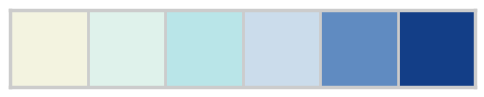

In [515]:
sns.set_style("whitegrid")
sns.set_context("poster", font_scale=0.7)


palette_cmap = ["#F3F3E0", "#DFF2EB", "#B9E5E8", "#CBDCEB", "#608BC1", "#133E87"]



sns.palplot(sns.color_palette(palette_cmap))

plt.show()


In [516]:
# sns.set_style("whitegrid")
# # sns.set(rc={"axes.facecolor": "#FFFFFF", "figure.facecolor": "#FFFFFF"})
# sns.set_context("poster", font_scale=0.7)

# # palette = ["#101B15", "#3A392B", "#7A7D58", "#FFF7B6", "#DD9954", "#94583C", "#601600"]
# palette_cmap = ["#F3F3E0", "#DFF2EB", "#B9E5E8", "#CBDCEB", "#608BC1", "#133E87"]
# cluster = ["#FCF596", "#FBD288", "#FF9C73", "#FF4545"]

# # sns.palplot(sns.color_palette(palette))
# sns.palplot(sns.color_palette(palette_cmap))
# # sns.palplot(sns.color_palette(cluster))
# plt.show()


<a id="7"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Basic Analysis</p>

Relative Plot Of Some Selected Features: A Data Subset


<Figure size 800x550 with 0 Axes>

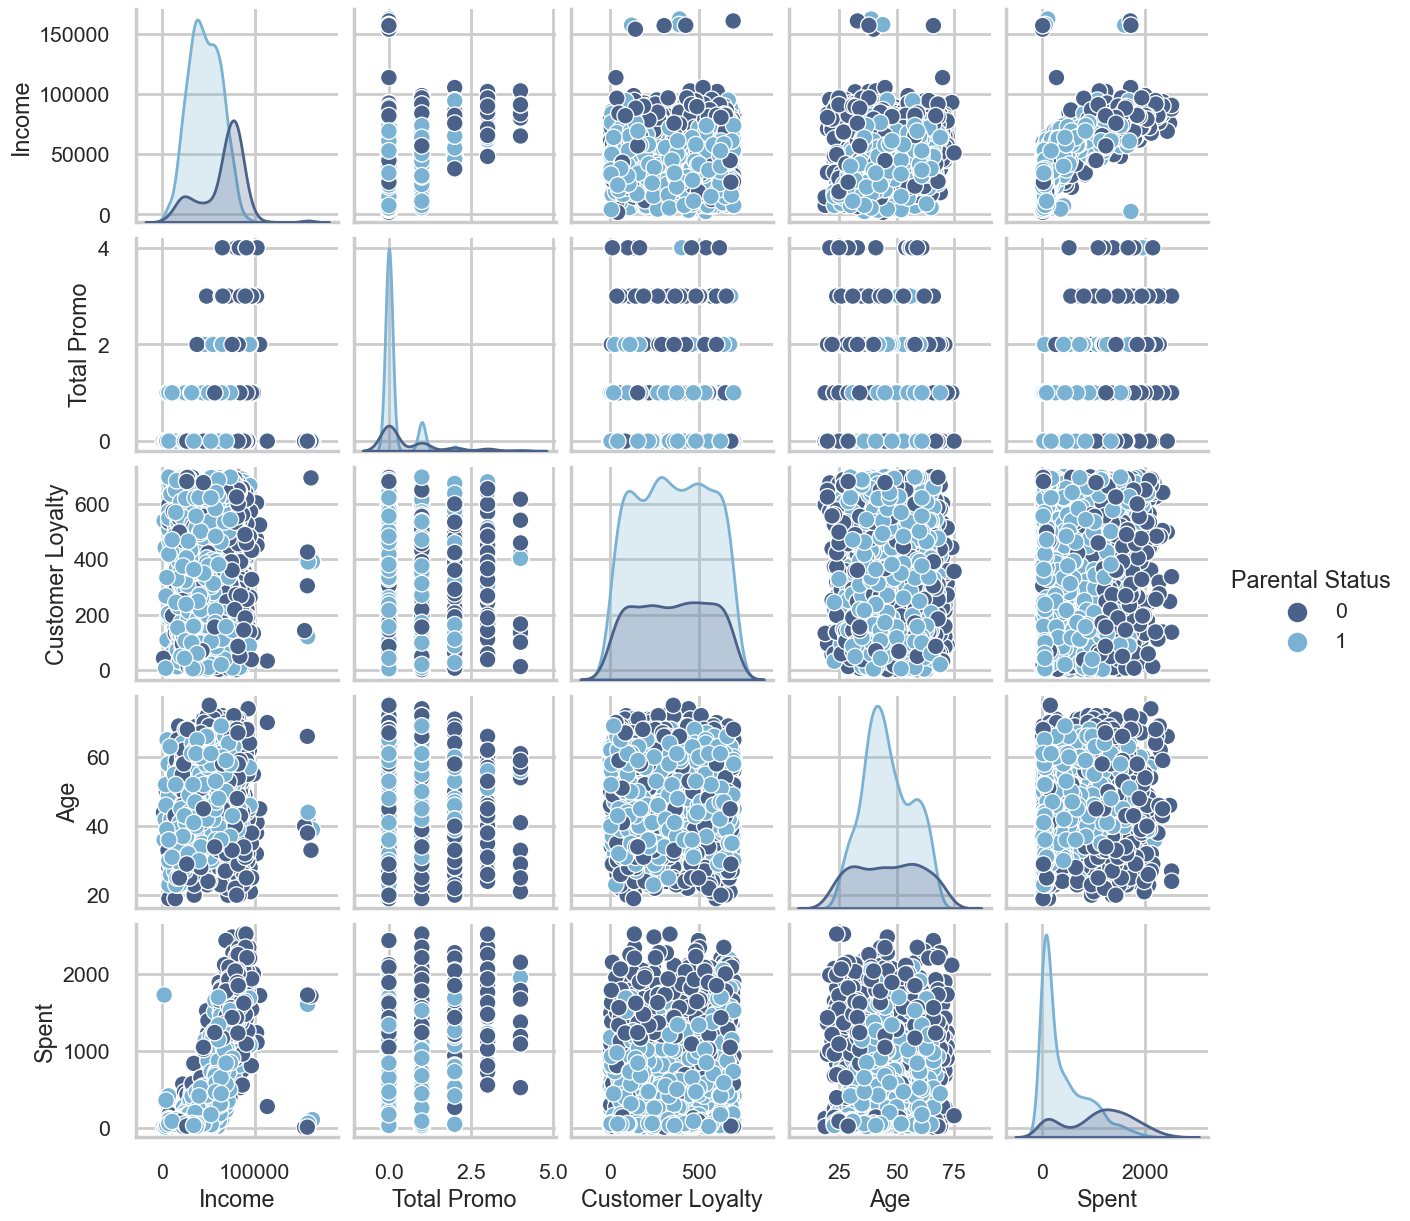

In [517]:
# 选择感兴趣的列进行绘图
To_Plot = ["Income", "Total Promo", "Customer Loyalty", "Age", "Spent", "Parental Status"]

# 打印信息以指示即将绘制的内容
print("Relative Plot Of Some Selected Features: A Data Subset")

# 使用 seaborn 的 pairplot 来绘制特征之间的关系
plt.figure()
sns.pairplot(data[To_Plot], hue="Parental Status", palette=(["#4A628A", "#7AB2D3"]))

# 显示图形
plt.show()

Let's have a look on the distribution of customer's age :


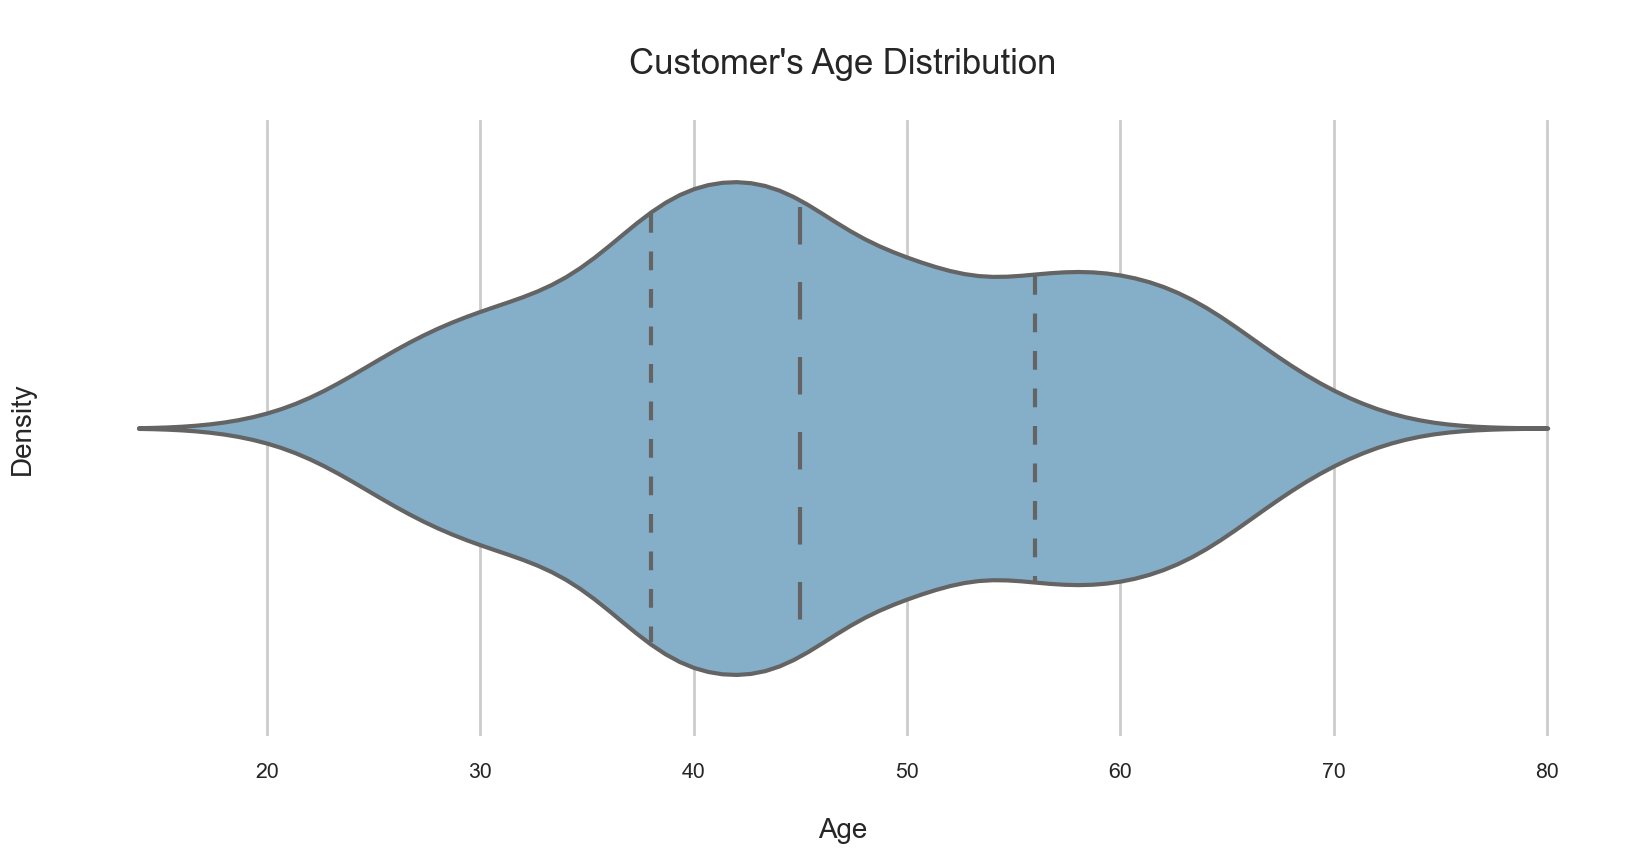

In [518]:
print(f"Let's have a look on the distribution of customer's age :")
plt.subplots(figsize=(20, 8))
p = sns.violinplot(data=data, x="Age", inner="quartile", color="#7AB2D3")
p.set_title("\nCustomer's Age Distribution\n", fontsize=25)
plt.ylabel("Density", fontsize=20)
plt.xlabel("\nAge", fontsize=20)
sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* We can see it's a normal distribution of customer's age.
* Most of the customers are from 36 to 50.


Let's have a look on the distribution of customer's income and spending :


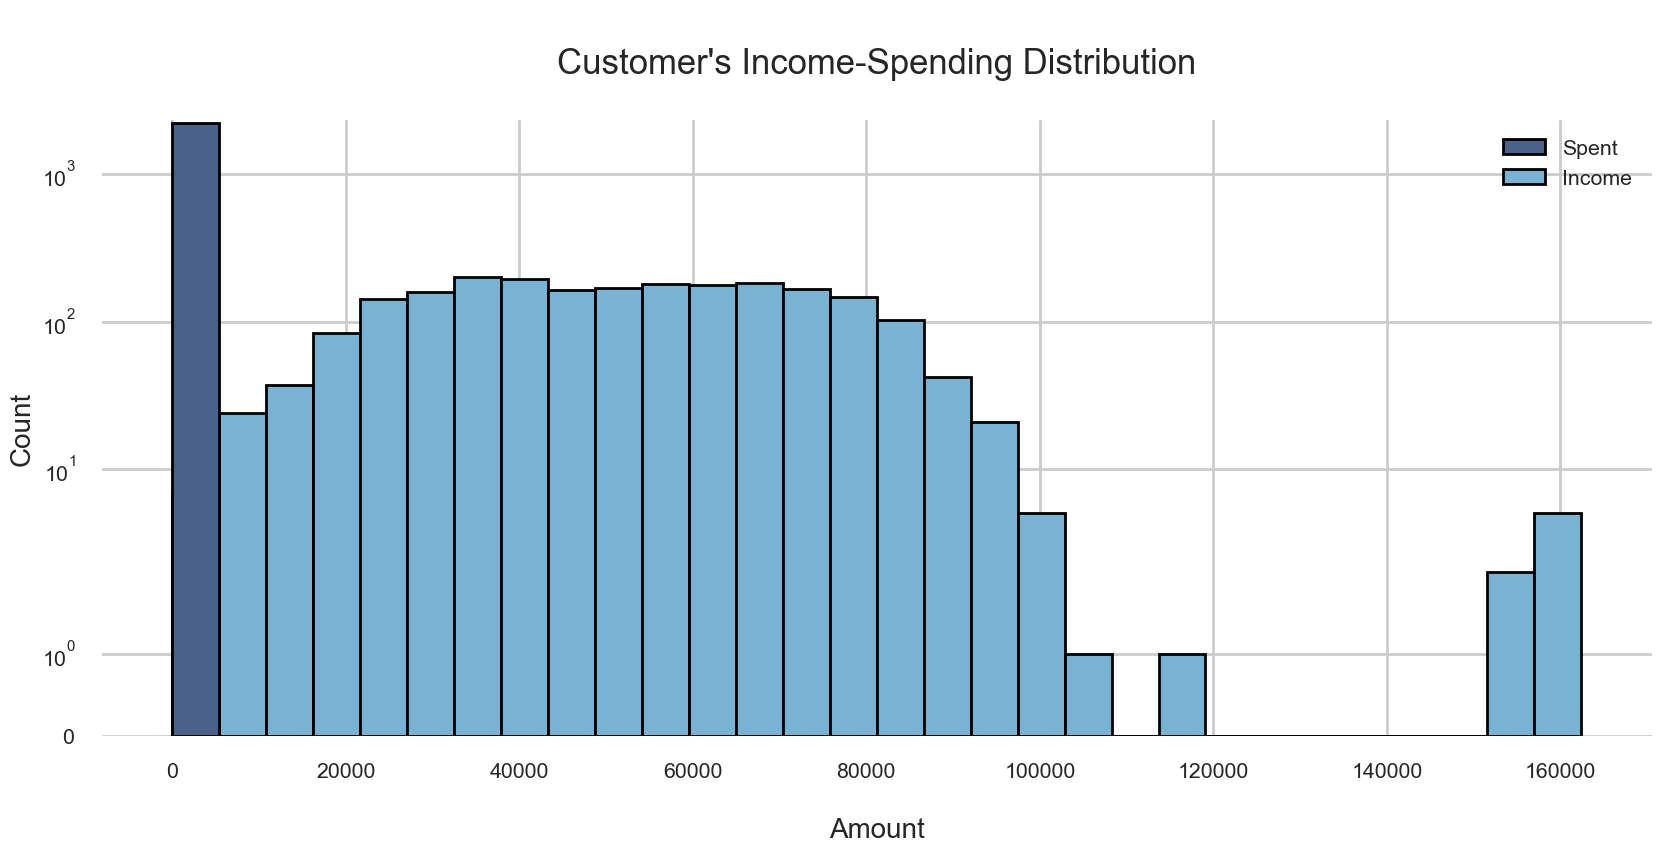

In [519]:
print(f"Let's have a look on the distribution of customer's income and spending :")
plt.subplots(figsize=(20, 8))
p = sns.histplot(data[["Spent","Income"]],palette=["#4A628A", "#7AB2D3"],kde=False,bins=30,alpha=1,fill=True,edgecolor="black")
# p.axes.lines[0].set_color(palette[0])
# p.axes.lines[1].set_color(palette[0])
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's Income-Spending Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAmount",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

**Insights:**

* Most of the customers income range is in between 20000 to 80000
* Bust almost all customers spend very few portion of their income.

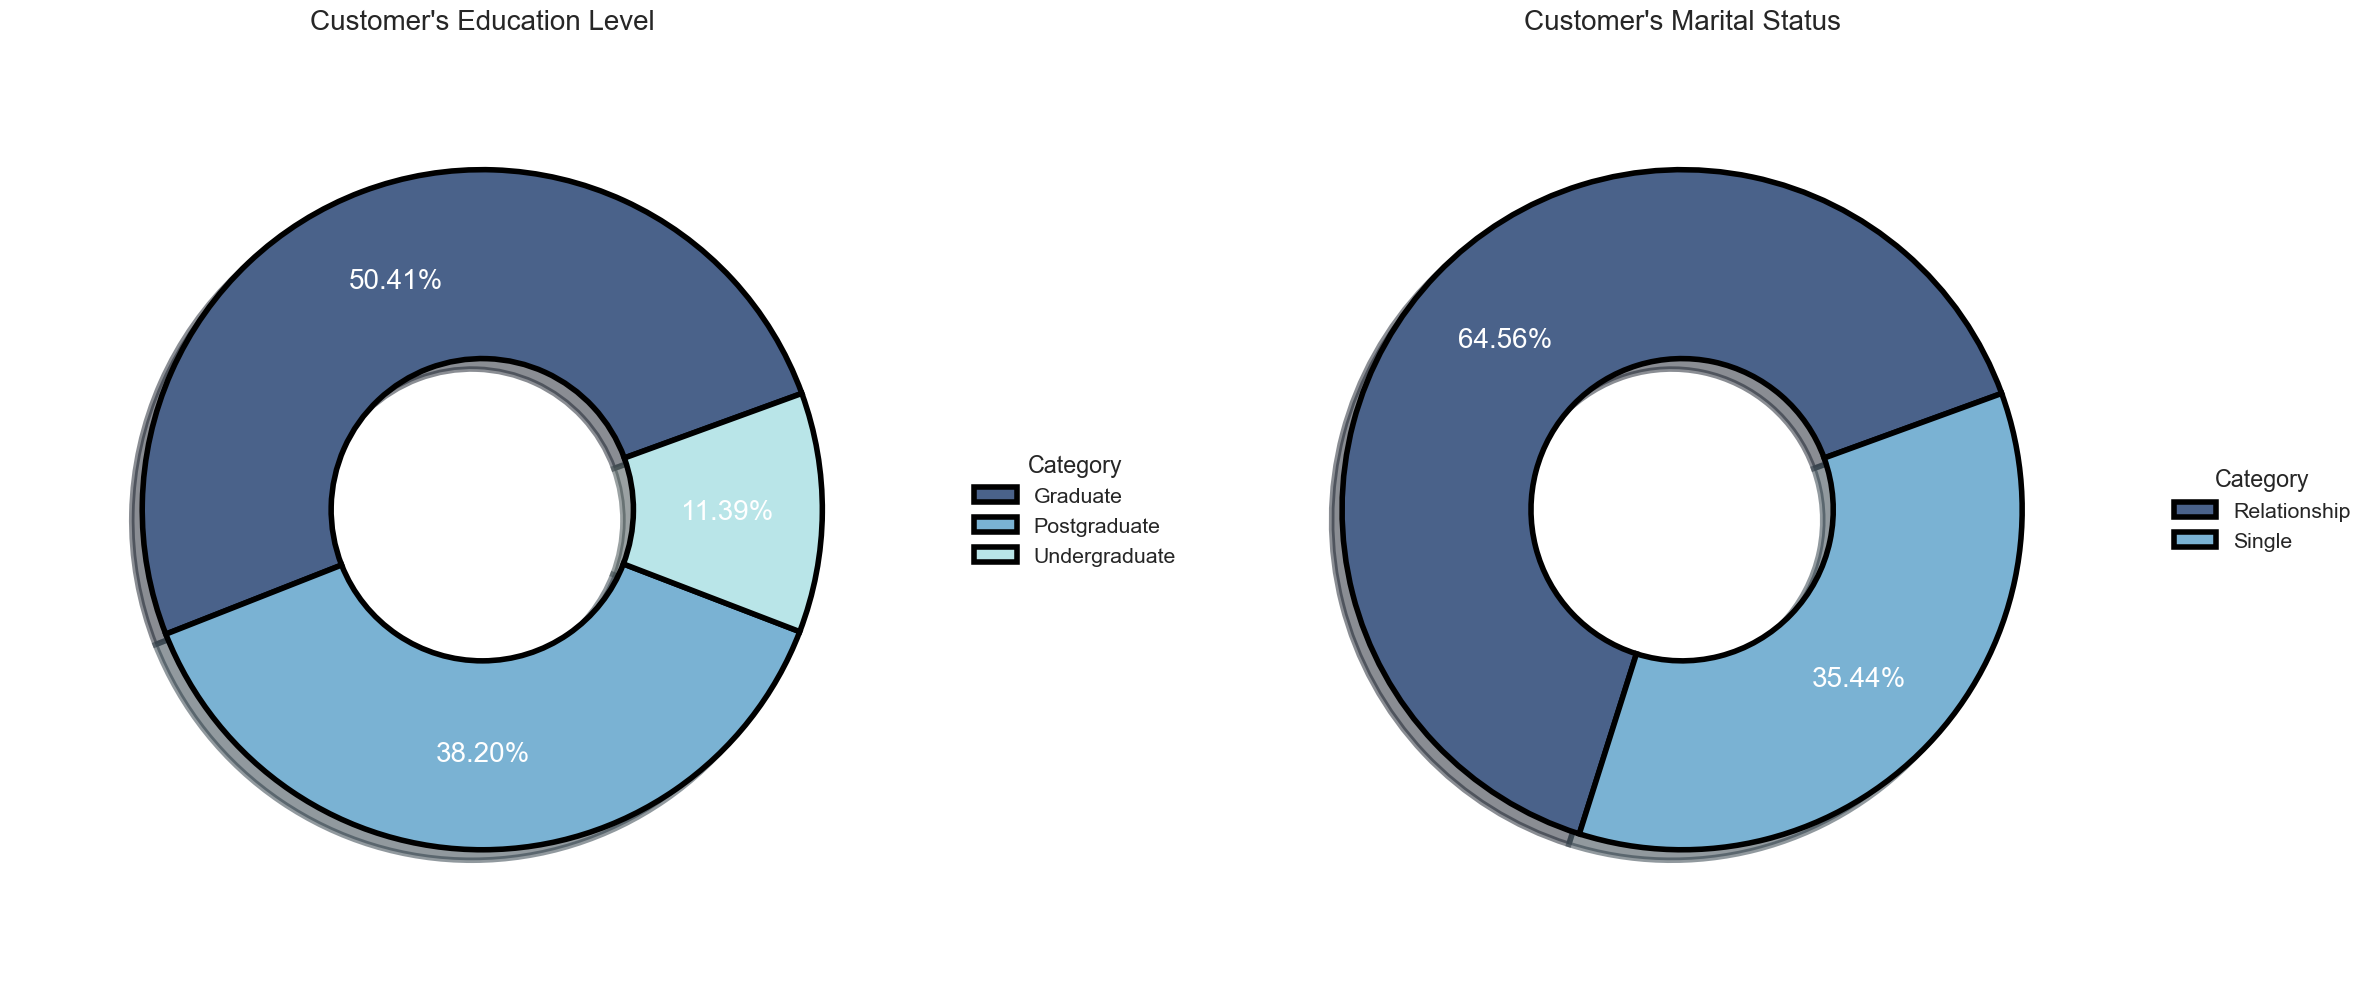

In [520]:


# 创建一个包含两个子图的图形
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# 第一个饼图：客户的教育水平
labels_edu = ["Graduate", "Postgraduate", "Undergraduate"]
size = 0.5
wedges, texts, autotexts = axes[0].pie([data["Education"].value_counts()[0],
                                        data["Education"].value_counts()[1],
                                        data["Education"].value_counts()[2]],
                                       explode=(0, 0, 0),
                                       textprops=dict(size=20, color="white"),
                                       autopct="%.2f%%",
                                       pctdistance=0.72,
                                       radius=0.9,
                                       colors=["#4A628A", "#7AB2D3","#B9E5E8"],
                                       shadow=True,
                                       wedgeprops=dict(width=size, edgecolor="black", linewidth=4),
                                       startangle=20)
axes[0].legend(wedges, labels_edu, title="Category", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), edgecolor="black")
axes[0].set_title("Customer's Education Level", fontsize=20)

# 第二个饼图：客户的婚姻状况
labels_marital = ["Relationship", "Single"]
wedges, texts, autotexts = axes[1].pie([data["Marital Status"].value_counts()[0],
                                        data["Marital Status"].value_counts()[1]],
                                       explode=(0, 0),
                                       textprops=dict(size=20, color="white"),
                                       autopct="%.2f%%",
                                       pctdistance=0.72,
                                       radius=0.9,
                                       colors=["#4A628A", "#7AB2D3"],
                                       shadow=True,
                                       wedgeprops=dict(width=size, edgecolor="black", linewidth=4),
                                       startangle=20)
axes[1].legend(wedges, labels_marital, title="Category", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), edgecolor="black")
axes[1].set_title("Customer's Marital Status", fontsize=20)

# 调整布局并显示图形
plt.tight_layout()
plt.show()


**Insights:**

* Customers have three education levels : Undergraduate, Graduate, Postgraduate
* 11.39% customers are in undergraduate level, 50.41% have completed graduation and 38.2% are on postgraduation level.
* 64.56% customers are in relationship, 35.44% are single.

Let's have a look on the distribution of customer's income and spending on basis of education level :


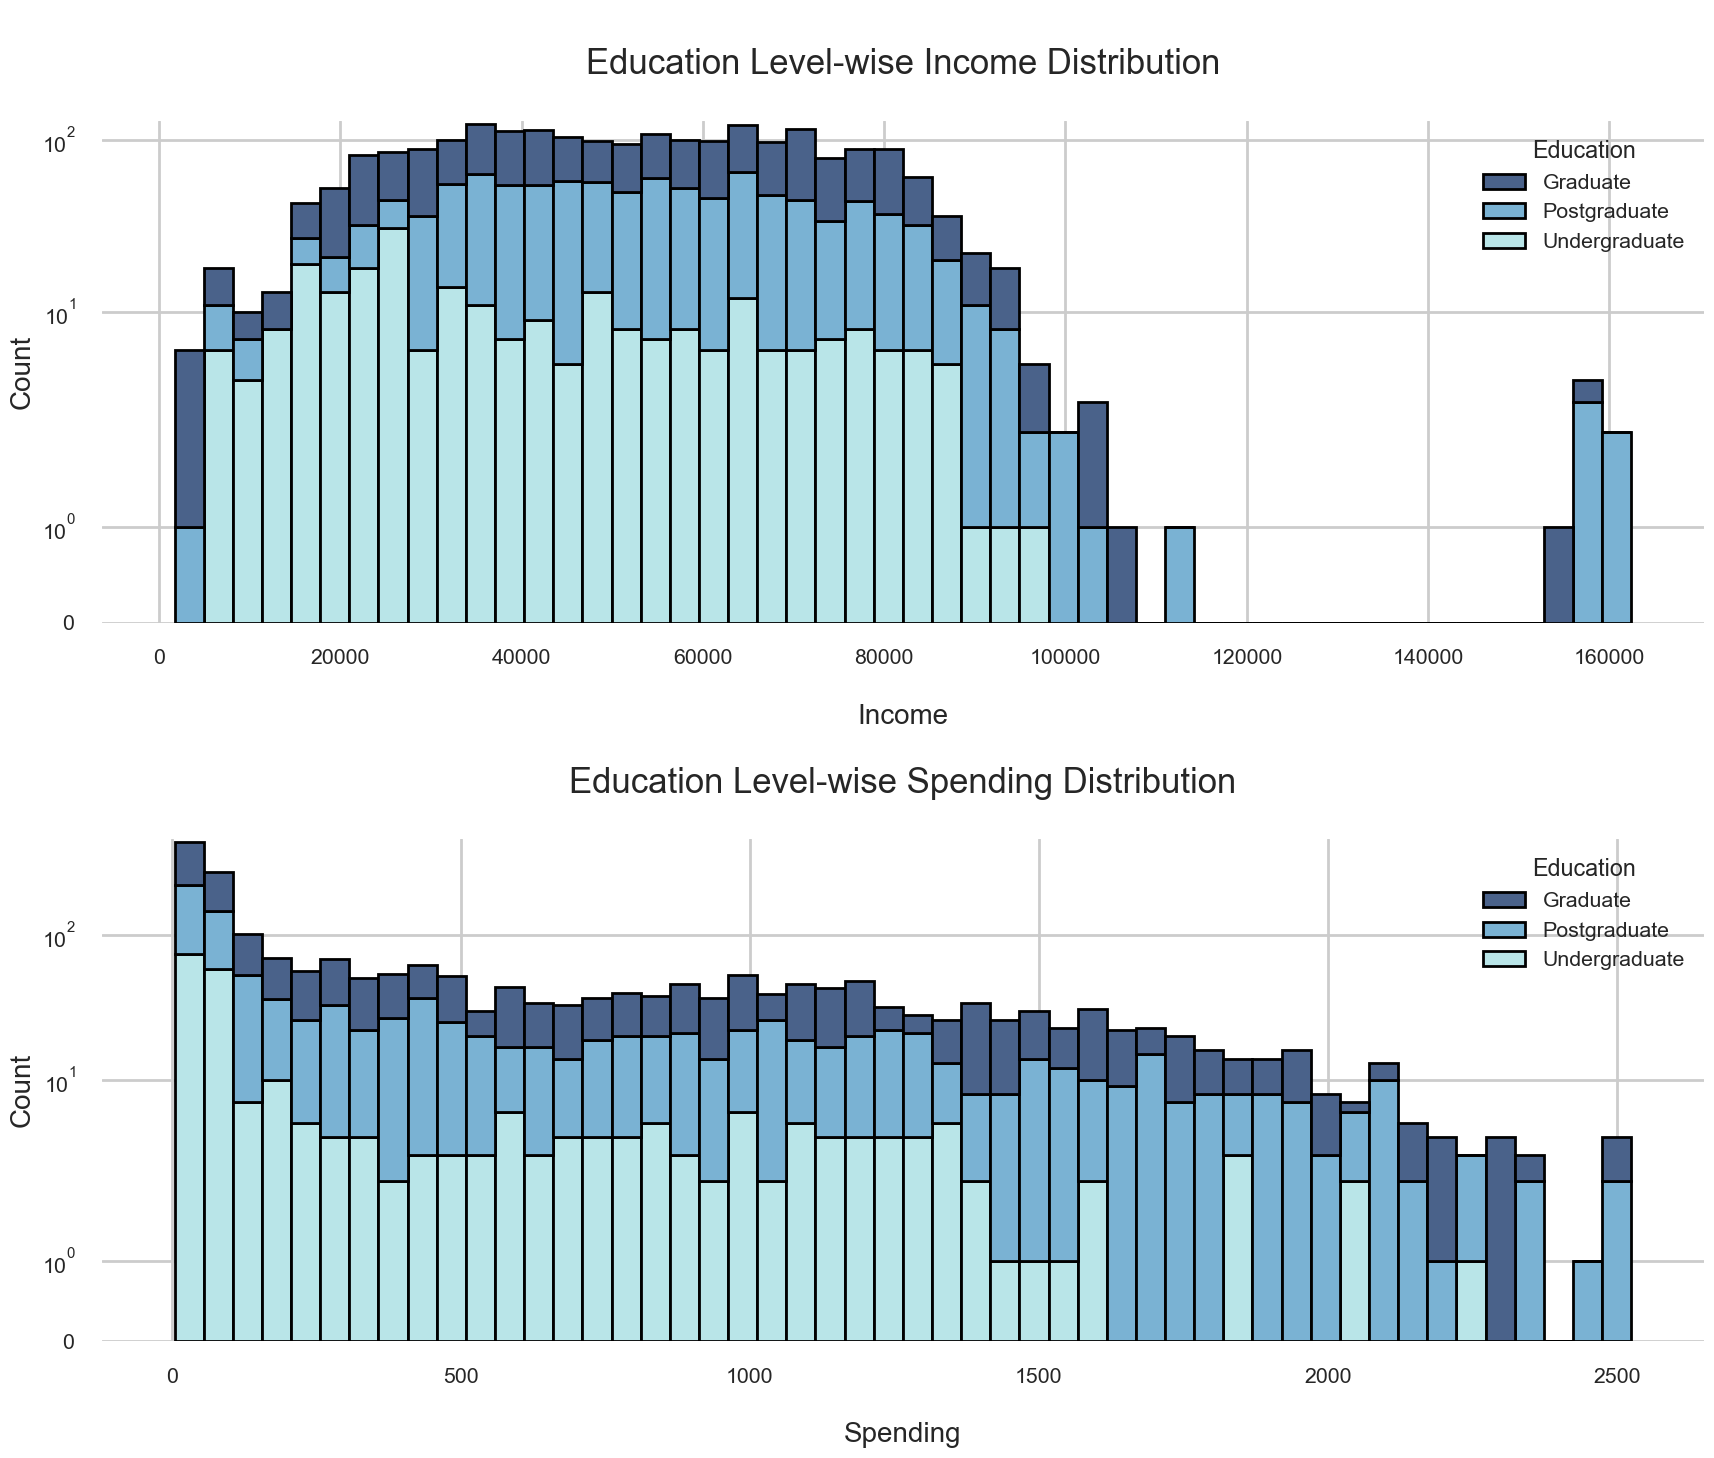

In [521]:
print(f"Let's have a look on the distribution of customer's income and spending on basis of education level :")

_, axes = plt.subplots(2,1,figsize=(20,16),sharex=False)
plt.tight_layout(pad=7.0)

sns.histplot(data=data,x="Income",hue="Education",multiple="stack",palette=["#4A628A", "#7AB2D3","#B9E5E8"],ax=axes[0],kde=False,bins=50,alpha=1,fill=True,edgecolor="black")
# axes[0].lines[0].set_color(palette[0])
# axes[0].lines[1].set_color(palette[0])
# axes[0].lines[2].set_color(palette[0])
axes[0].set_yscale("symlog")
axes[0].set_title("\nEducation Level-wise Income Distribution\n",fontsize=25)
axes[0].set_ylabel("Count",fontsize=20)
axes[0].set_xlabel("\nIncome",fontsize=20)

sns.histplot(data=data,x="Spent",hue="Education",multiple="stack",palette=["#4A628A", "#7AB2D3","#B9E5E8"],ax=axes[1],kde=False,bins=50,alpha=1,fill=True,edgecolor="black")
# axes[1].lines[0].set_color(palette[0])
# axes[1].lines[1].set_color(palette[0])
# axes[1].lines[2].set_color(palette[0])
axes[1].set_yscale("symlog")
axes[1].set_title("\nEducation Level-wise Spending Distribution\n",fontsize=25)
axes[1].set_ylabel("Count",fontsize=20)
axes[1].set_xlabel("\nSpending",fontsize=20)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the undergraduate level customer's income range is in between 10000 to 80000 and spending in between 0 to 1400.
* Most of the graduate level customer's income range is in between 20000 to 85000 and spending in between 0 to 2000.
* Most of the postgraduate level customer's income range is in between 30000 to 80000 and spending in between 0 to 2000.

Let's have a look on the distribution of customer's income and spending on basis of marital and parental status :


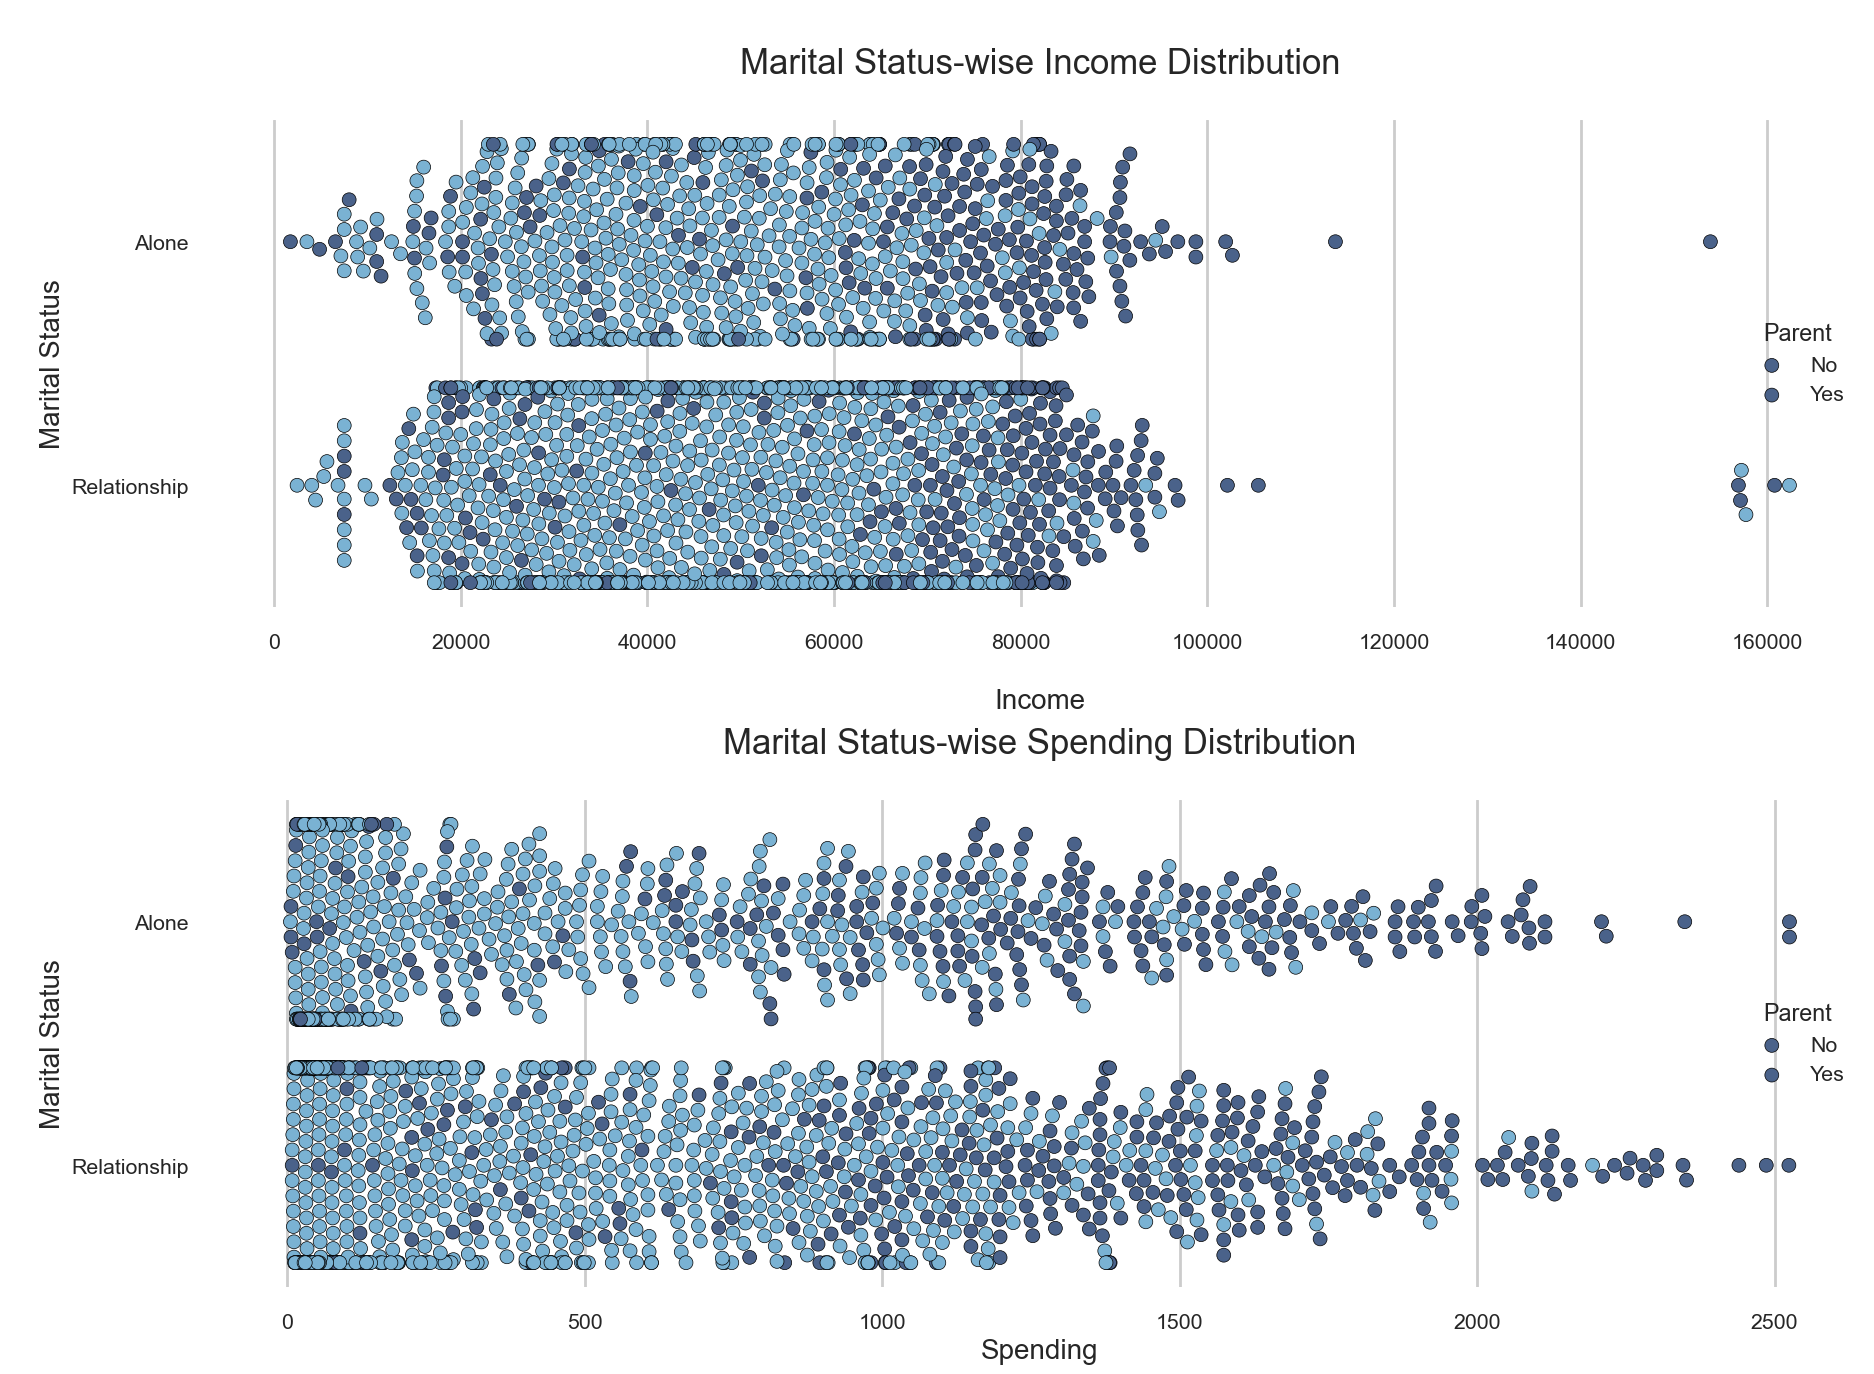

In [522]:
print(f"Let's have a look on the distribution of customer's income and spending on basis of marital and parental status :")

_, axes = plt.subplots(2,1,figsize=(20,15),sharex=False)
plt.tight_layout(pad=6.0)

sns.swarmplot(x=data["Income"],y=data["Marital Status"],hue=data["Parental Status"],palette=["#4A628A", "#7AB2D3"],ax=axes[0],marker="o",size=10,alpha=1,linewidth=0.5,edgecolor="black")
axes[0].legend(["No","Yes"],title="Parent", edgecolor = "#1c1c1c",loc="center right")
axes[0].set_title("\nMarital Status-wise Income Distribution\n",fontsize=25)
axes[0].set_xlabel("\nIncome",fontsize=20)
axes[0].set_ylabel("\nMarital Status",fontsize=20)

sns.swarmplot(x=data["Spent"],y=data["Marital Status"],hue=data["Parental Status"],palette=["#4A628A", "#7AB2D3"],ax=axes[1],marker="o",size=10,alpha=1,linewidth=0.5,edgecolor="black")
axes[1].legend(["No","Yes"],title="Parent", edgecolor = "#1c1c1c",loc="center right")
axes[1].set_title("\nMarital Status-wise Spending Distribution\n",fontsize=25)
axes[1].set_xlabel("Spending",fontsize=20)
axes[1].set_ylabel("\nMarital Status",fontsize=20)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* Most of the customers live together. 
* Customers who live together and are parents earn much and spend much.


Let's have a look on the distribution of customer's Income based on number of children:


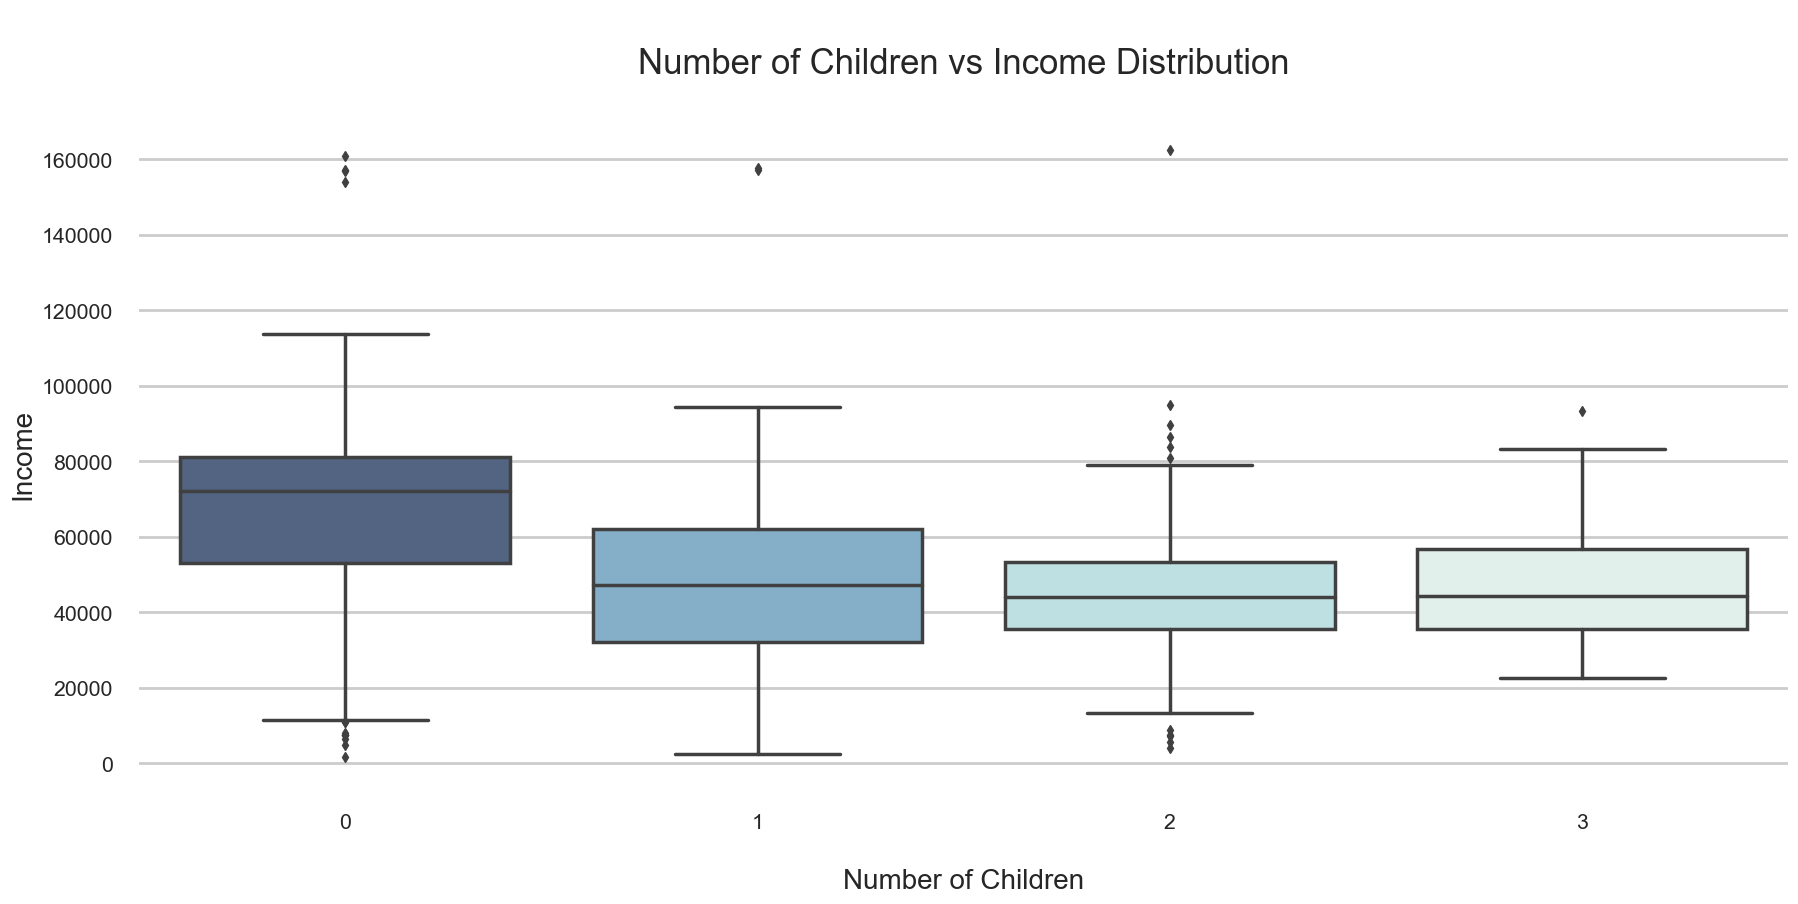

In [523]:
print(f"Let's have a look on the distribution of customer's Income based on number of children:")

# Create a figure with subplots
_, axes = plt.subplots(1, 1, figsize=(20, 10), sharex=False)
plt.tight_layout(pad=6.0)

# Boxplot for Spending based on Number of Children
sns.boxplot(x=data["Children"], y=data["Income"], palette=["#4A628A", "#7AB2D3","#B9E5E8","#DFF2EB"], ax=axes, linewidth=2.5)
axes.set_title("\nNumber of Children vs Income Distribution\n", fontsize=25)
axes.set_xlabel("\nNumber of Children", fontsize=20)
axes.set_ylabel("Income", fontsize=20)

# Remove unnecessary spines
sns.despine(left=True, bottom=True)
plt.show()


Let's have a look on the relationship between customer's income and number of children:


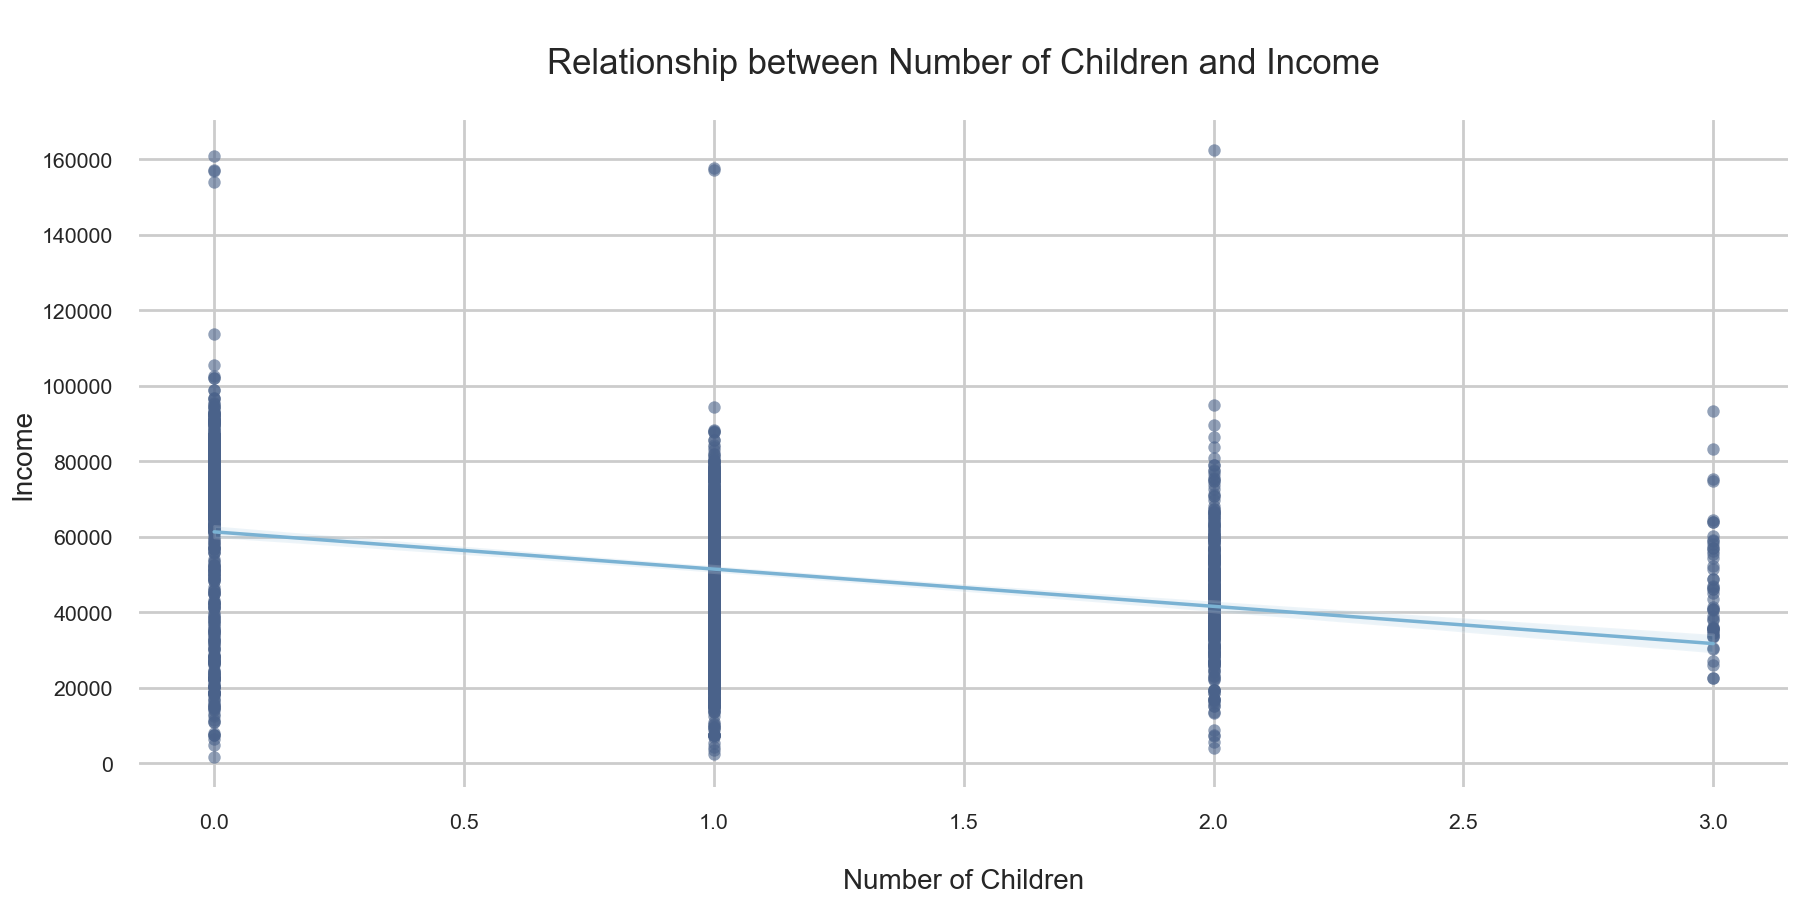

In [524]:
print(f"Let's have a look on the relationship between customer's income and number of children:")

# Create a figure with subplots
_, axes = plt.subplots(1, 1, figsize=(20, 10), sharex=False)
plt.tight_layout(pad=6.0)

# Regression plot for Spending vs Number of Children
sns.regplot(x=data["Children"], y=data["Income"], ax=axes, 
            scatter_kws={"s": 80, "alpha": 0.6, "color": "#4A628A"}, 
            line_kws={"color": "#7AB2D3", "linewidth": 2.5})

axes.set_title("\nRelationship between Number of Children and Income\n", fontsize=25)
axes.set_xlabel("\nNumber of Children", fontsize=20)
axes.set_ylabel("Income", fontsize=20)

# Remove unnecessary spines
sns.despine(left=True, bottom=True)
plt.show()


**Insights from 2 figures above:**

* 待补充

Let's have a look on the relationship between customer's income and discount purchases:


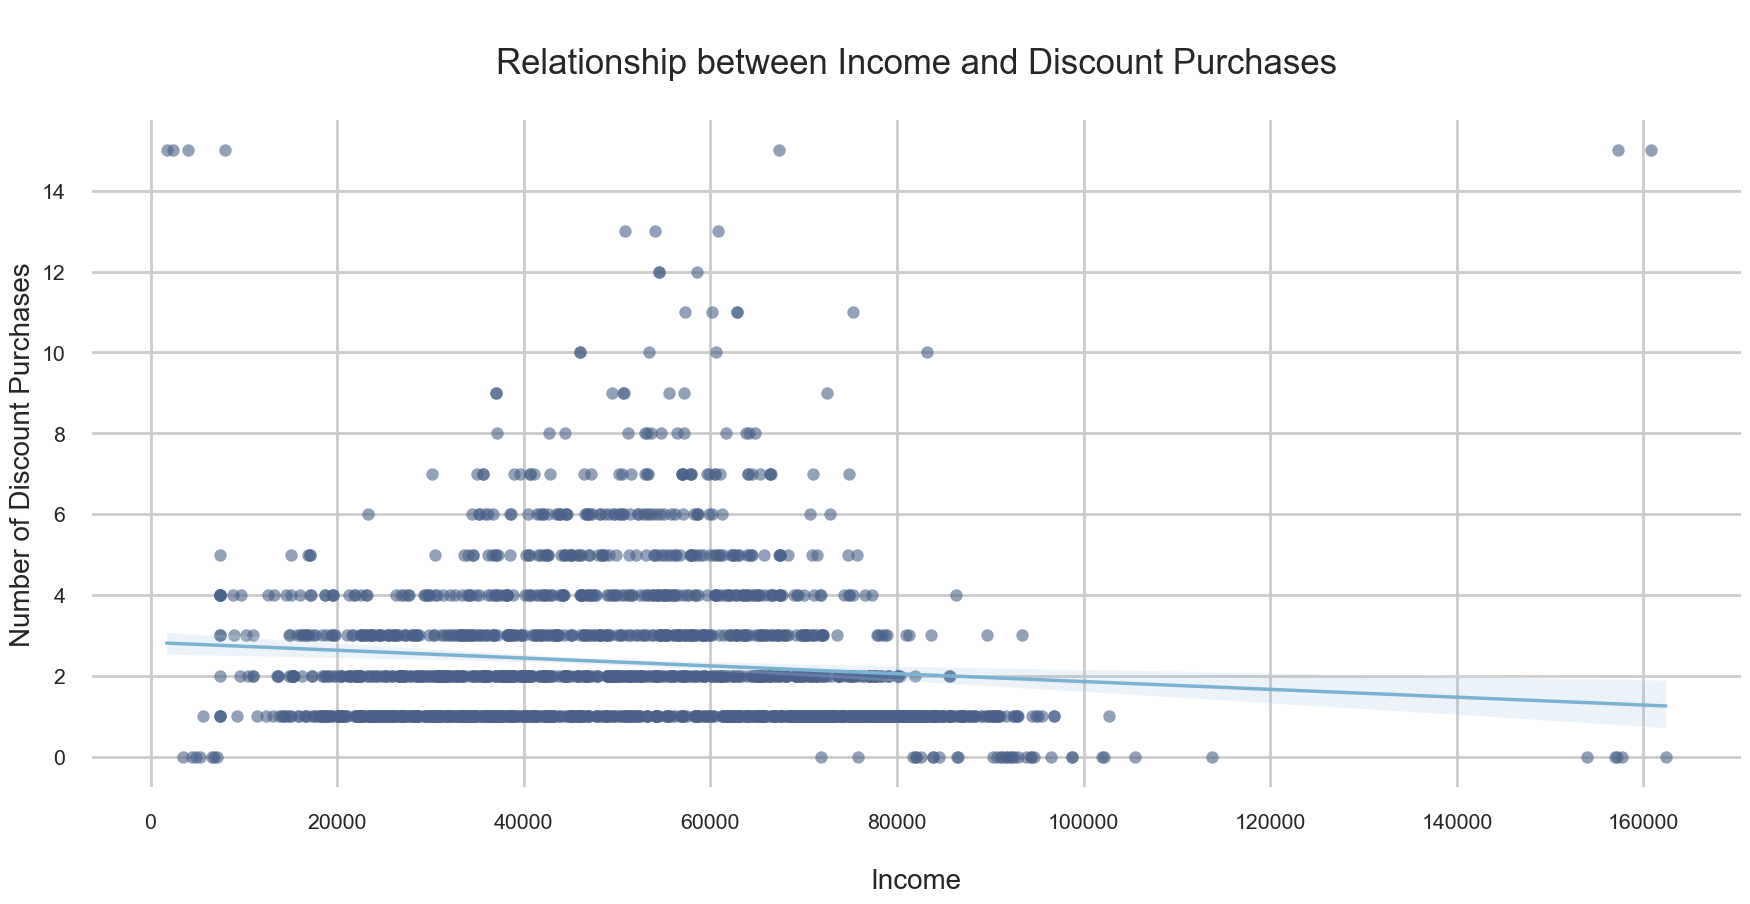

In [525]:
print(f"Let's have a look on the relationship between customer's income and discount purchases:")

# Create a figure with subplots
_, axes = plt.subplots(1, 1, figsize=(20, 10), sharex=False)
plt.tight_layout(pad=6.0)

# Regression plot for Discount Purchases vs Income
sns.regplot(x=data["Income"], y=data["Discount Purchases"], ax=axes, 
            scatter_kws={"s": 80, "alpha": 0.6, "color": "#4A628A"}, 
            line_kws={"color": "#7AB2D3", "linewidth": 2.5})

axes.set_title("\nRelationship between Income and Discount Purchases\n", fontsize=25)
axes.set_xlabel("\nIncome", fontsize=20)
axes.set_ylabel("Number of Discount Purchases", fontsize=20)

# Remove unnecessary spines
sns.despine(left=True, bottom=True)
plt.show()


**Insights:**

* 待补充

<a id="7"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Correlation Analysis</p>

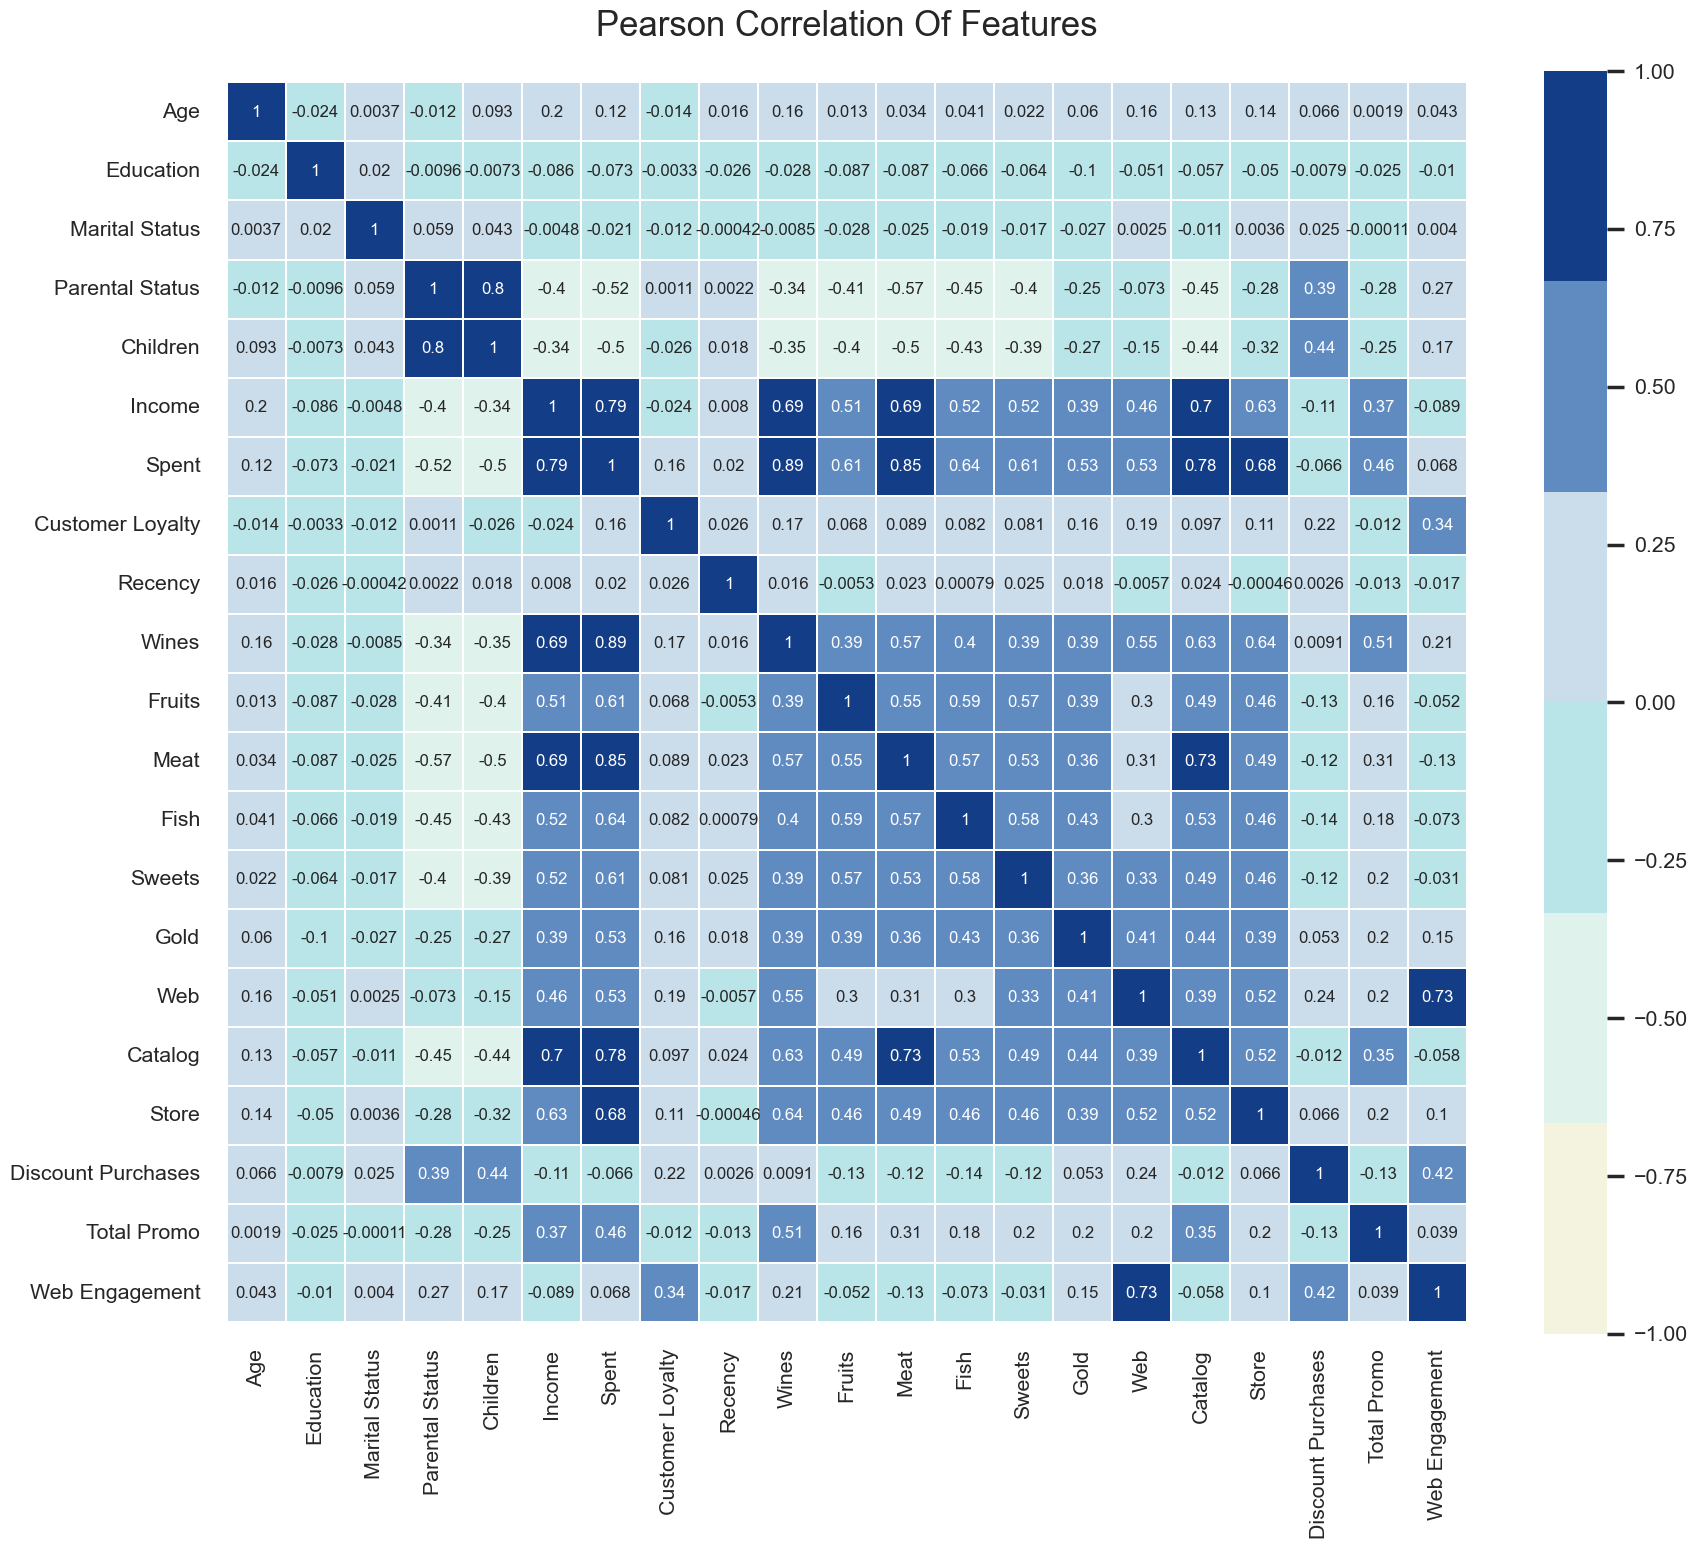

In [526]:
catcol = ["Education","Marital Status"]
le = LabelEncoder()
for col in catcol:
        data[col] = le.fit_transform(data[col])


plt.subplots(figsize =(20, 20))

sns.heatmap(data.drop(columns="ID").corr(), cmap = palette_cmap, square=True, cbar_kws=dict(shrink =.82), 
            annot=True, vmin=-1, vmax=1, linewidths=0.1,linecolor='white',annot_kws=dict(fontsize =12))
plt.title("Pearson Correlation Of Features\n", fontsize=25)
plt.xticks(rotation=90)
plt.show()

**Insights:**
* 待修正
* High correlation between customer's income and spending. Also high correlation between buying wine, meat and buying through catalog and stores with income and spending.
* High correlation between buying meat and buying through catalog.

<a id="9"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Dimensionality Reduction</p>

In [527]:
dataC = data.copy()
scaler = StandardScaler()
dataC = scaler.fit_transform(dataC)
scaled_data = pd.DataFrame(dataC, columns= data.columns)
print("After scaling, let's have a glimpse of the scaled dataset :")
scaled_data.head().style.set_properties(**{"background-color": "#4A628A","color":"#DFF2EB","border": "1.5px solid black"})

After scaling, let's have a glimpse of the scaled dataset :


,ID,Age,Education,Marital Status,Parental Status,Children,Income,Spent,Customer Loyalty,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,Web Engagement
0,-0.018837,1.018352,-0.893586,-1.349603,-1.581139,-1.264598,0.287105,1.676245,1.527721,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,0.852576,1.426865,2.503607,-0.555814,0.351030,-0.439160,1.568024
1,-1.050626,1.274785,-0.893586,-1.349603,0.632456,1.404572,-0.260882,-0.963297,-1.189011,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,-0.733642,-1.126420,-0.571340,-1.171160,-0.168701,-0.439160,-0.956335
2,-0.444797,0.334530,-0.893586,0.740959,-1.581139,-1.264598,0.913196,0.280110,-0.206048,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,-0.037254,1.426865,-0.229679,1.290224,-0.688432,-0.439160,0.726571
3,0.183824,-1.289547,-0.893586,0.740959,0.632456,0.069987,-1.176114,-0.920135,-1.060584,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,-0.752987,-0.761665,-0.913000,-0.555814,-0.168701,-0.439160,-0.395366
4,-0.080437,-1.033114,0.571657,0.740959,0.632456,0.069987,0.294307,-0.307562,-0.951915,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,-0.559545,0.332600,0.111982,0.059532,1.390492,-0.439160,0.165602


In [528]:
scaled_dataC = scaled_data.copy()
pca = PCA(n_components = 3,random_state = 42)
scaled_dataC = pca.fit_transform(scaled_dataC)
pca_data = pd.DataFrame(scaled_dataC, columns=["col1","col2", "col3"])

print("Let's have a glimpse of the PCA transformed dataset :")
pca_data.head(15).T.style.set_properties(**{"background-color": "#4A628A","color":"#DFF2EB","border": "1.5px solid black"})

Let's have a glimpse of the PCA transformed dataset :


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
col1,4.772287,-2.773383,2.105845,-2.648298,-0.472222,0.558605,0.538310,-2.129909,-2.662302,-3.315978,-1.990505,3.301414,-1.497468,-1.957015,4.055031
col2,0.957577,-0.821555,-0.015246,-0.966718,0.558950,1.011117,1.750404,0.294987,-0.153018,1.089331,-1.414136,-2.528696,1.382316,-1.744378,0.448786
col3,-1.954468,1.572212,-0.431489,-0.277370,-0.029824,0.609964,-1.332598,-1.153683,-0.630727,0.929461,-2.076894,-0.666447,1.266292,-2.367252,1.354581


In [529]:
x = pca_data["col1"]
y = pca_data["col2"]
z = pca_data["col3"]

print(f"Let's have a look on the dataset after dimensionality reduction :")

fig = go.Figure(data = [go.Scatter3d(x=x, y=y, z=z,mode='markers',
                marker = dict(size=10, color="#4A628A", opacity=0.8))])
fig.update_layout(title=dict(text= "Dataset After Diemsionality Reduction[3D Projection]",
                             y=0.97,x=0.5,xanchor= "center",yanchor= "top",font_color="black"),
                  scene=dict(xaxis = dict(title="col1",backgroundcolor="#CBDCEB",showbackground=True,showgrid=True, gridwidth=2, gridcolor='white',zerolinecolor="white"),
                             yaxis = dict(title="col2",backgroundcolor="#CBDCEB",showbackground=True,showgrid=True, gridwidth=2, gridcolor='white',zerolinecolor="white"),
                             zaxis = dict(title="col3",backgroundcolor="#CBDCEB",showbackground=True,showgrid=True, gridwidth=2, gridcolor='white',zerolinecolor="white")),
                  margin=dict(l=0, r=0, b=0, t=0),paper_bgcolor="#CBDCEB")
fig.show()

Let's have a look on the dataset after dimensionality reduction :


<a id="10"></a>
# <p style="padding:10px;background-color:#4A628A;margin:0;color:#DFF2EB;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">K-means Clustering</p>

Elbow Method for determining the number of clusters :


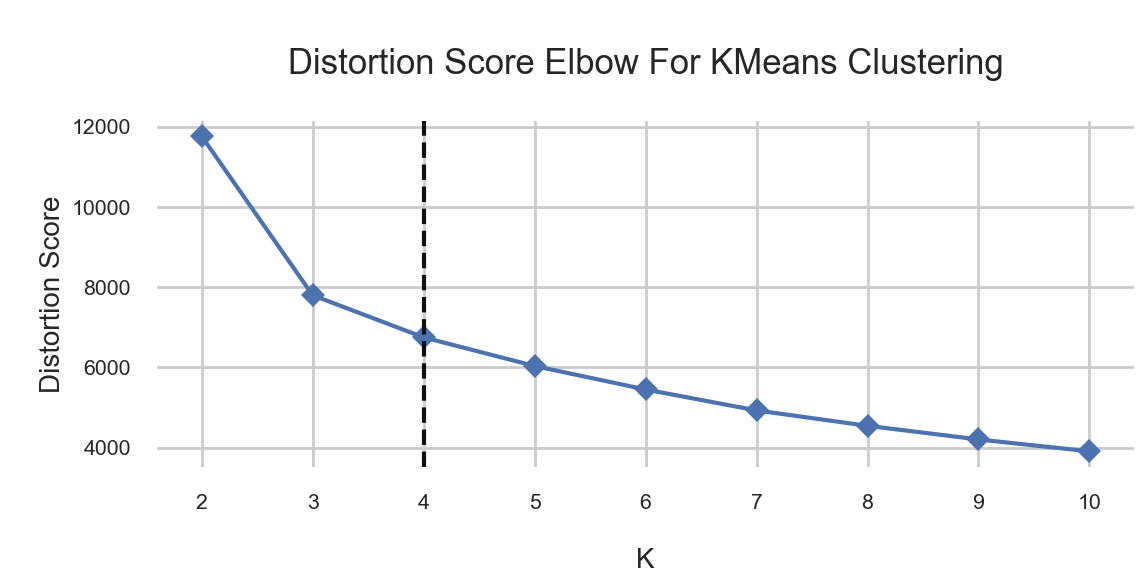

In [530]:
print("Elbow Method for determining the number of clusters :")
_, axes = plt.subplots(figsize=(20,8))

elbow = KElbowVisualizer(KMeans(), k=10, timings=False, locate_elbow=True, size=(1260,450))
elbow.fit(pca_data)

axes.set_title("\nDistortion Score Elbow For KMeans Clustering\n",fontsize=25)
axes.set_xlabel("\nK",fontsize=20)
axes.set_ylabel("\nDistortion Score",fontsize=20)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

* We will use **k = 4**, thus there will be **four clusters** in our dataset.
* We will use **KMeans Algorithm** for clustering.

In [531]:
km = KMeans(n_clusters = 4,random_state = 42)
# ac = AgglomerativeClustering(n_clusters=4)

y_km = km.fit_predict(pca_data)
pca_data["Clusters"] = y_km
data["Clusters"]= y_km

In [532]:
print(f"Let's have a look on the dataset after clustering :")

fig = go.Figure(data=[go.Scatter3d(x=x, y=y, z=z, mode='markers',
                marker=dict(size=10, color=pca_data["Clusters"], colorscale=["#DFF2EB", "#B9E5E8", "#7AB2D3", "#4A628A"], opacity=1))])
fig.update_layout(title=dict(text="Dataset After Clustering[3D Projection]",
                             y=0.97, x=0.5, xanchor="center", yanchor="top", font_color="black"),
                  scene=dict(xaxis=dict(title="col1", backgroundcolor="#CBDCEB", showbackground=True, showgrid=True, gridwidth=2, gridcolor='white', zerolinecolor="white"),
                             yaxis=dict(title="col2", backgroundcolor="#CBDCEB", showbackground=True, showgrid=True, gridwidth=2, gridcolor='white', zerolinecolor="white"),
                             zaxis=dict(title="col3", backgroundcolor="#CBDCEB", showbackground=True, showgrid=True, gridwidth=2, gridcolor='white', zerolinecolor="white")),
                  margin=dict(l=0, r=0, b=0, t=0), paper_bgcolor="#CBDCEB")
fig.show()


Let's have a look on the dataset after clustering :


**Insights:**

* 待补充

Let's have a look on the characteristics of the clusters on the basis of income and spending :


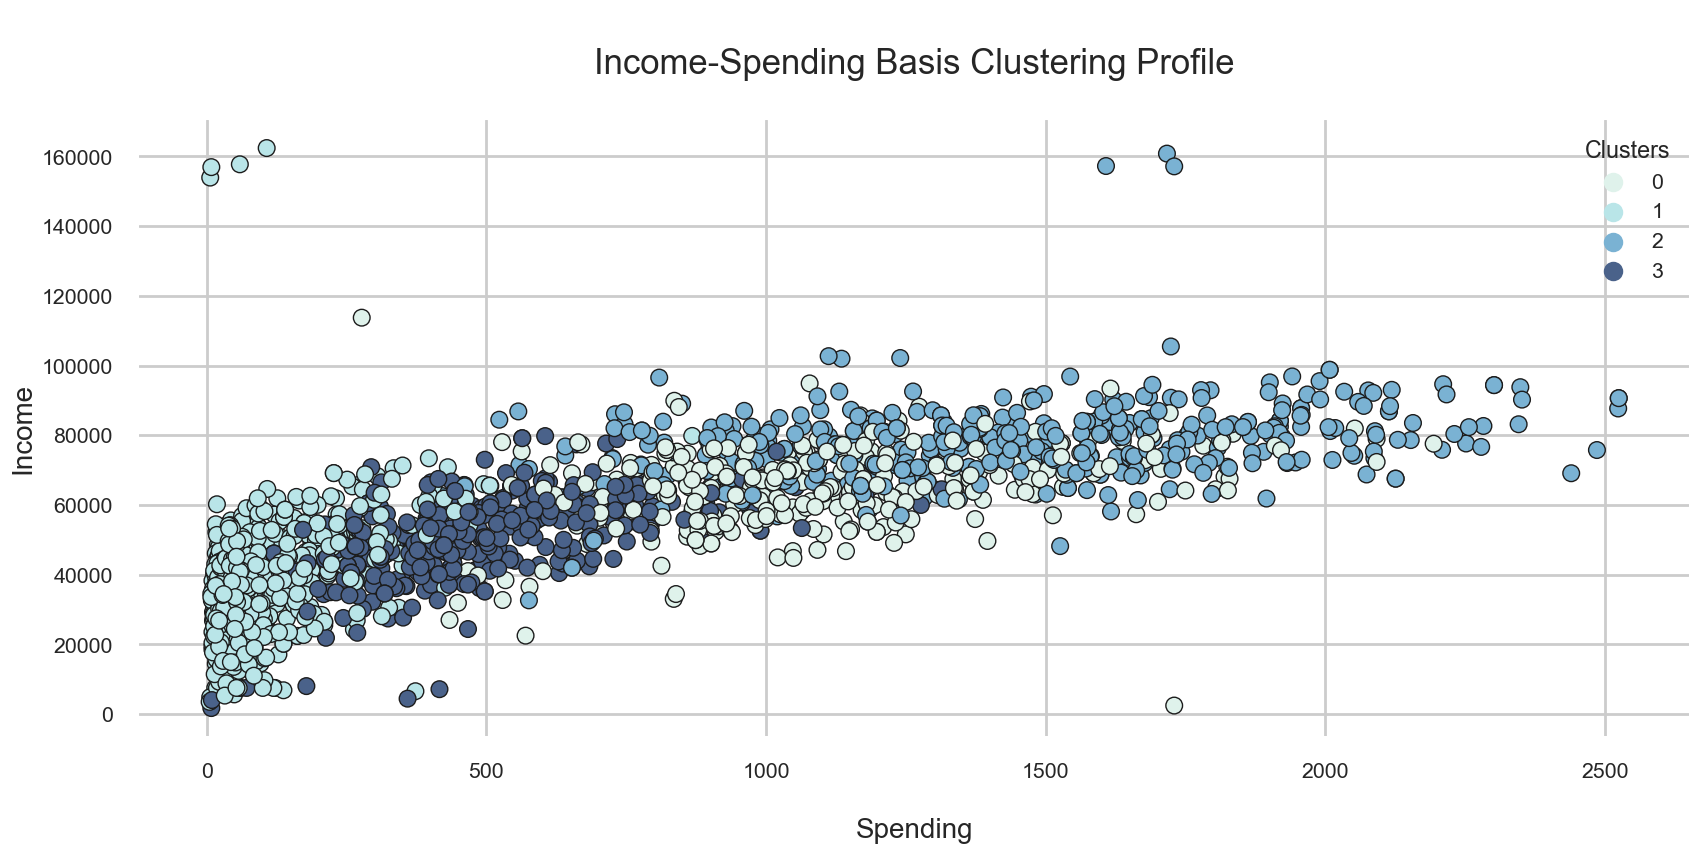

In [533]:
print(f"Let's have a look on the characteristics of the clusters on the basis of income and spending :")

_, axes = plt.subplots(figsize=(20,8))
sns.scatterplot(x=data["Spent"], y=data["Income"], hue=data["Clusters"], palette=["#DFF2EB", "#B9E5E8", "#7AB2D3", "#4A628A"], sizes=60, alpha=1, edgecolor="#1c1c1c", linewidth=1)
axes.set_title("\nIncome-Spending Basis Clustering Profile\n", fontsize=25)
axes.set_ylabel("Income", fontsize=20)
axes.set_xlabel("\nSpending", fontsize=20)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**
* change
* Most of the cluster 0 customers income range is in between 5000 to 40000 and spending range is in between 0 to 500.
* Most of the cluster 1 customers income range is in between 65000 to 85000 and spending range is in between 550 to 2000.
* Most of the cluster 2 customers income range is in between 50000 to 80000 and spending range is in between 250 to 1800.
* Most of the cluster 3 customers income range is in between 40000 to 60000 and spending range is in between 0 to 500.


**Insights:**
* change
* Most of the cluster 0 customers spending range is in between 0 to 500.
* Most of the cluster 1 customers spending range is in between 550 to 2000.
* Most of the cluster 2 customers spending range is in between 250 to 1800.
* Most of the cluster 3 customers spending range is in between 0 to 500.


Let's have a look on the characteristics of the clusters on the basis of accepting promotions :


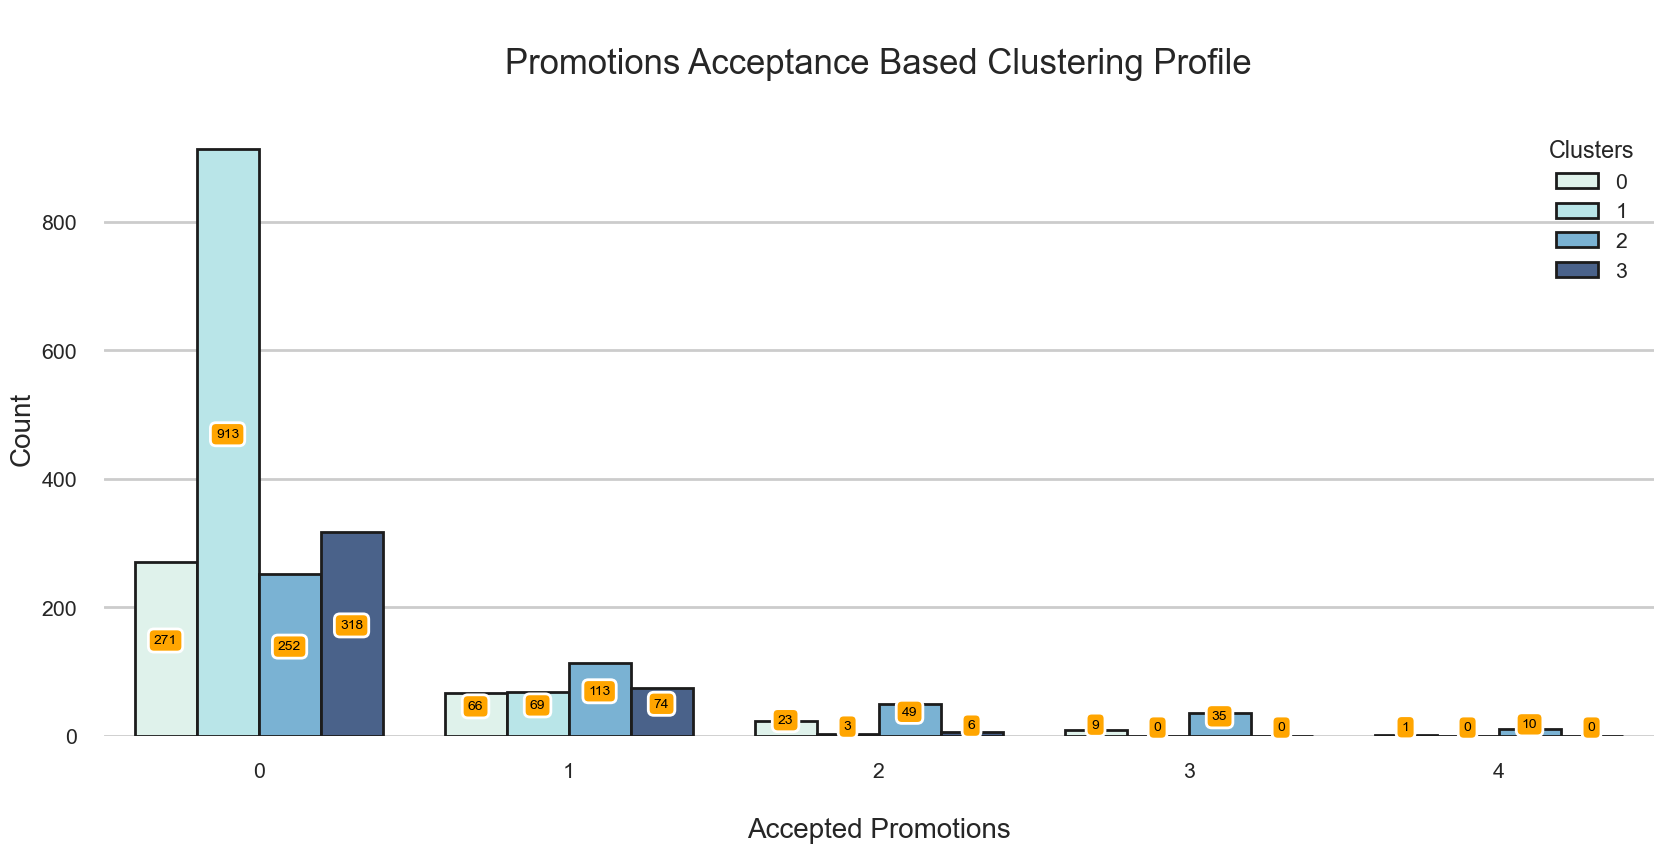

In [534]:
print(f"Let's have a look on the characteristics of the clusters on the basis of accepting promotions :")

plt.subplots(figsize=(20, 8))
p = sns.countplot(x=data["Total Promo"],hue=data["Clusters"], palette=["#DFF2EB", "#B9E5E8", "#7AB2D3", "#4A628A"], saturation=1, edgecolor="#1c1c1c", linewidth=2)
p.axes.set_yscale("linear")
p.axes.set_title("\nPromotions Acceptance Based Clustering Profile\n", fontsize=25)
p.axes.set_ylabel("Count", fontsize=20)
p.axes.set_xlabel("\nAccepted Promotions", fontsize=20)
p.axes.set_xticklabels(p.get_xticklabels(), rotation=0)
for container in p.containers:
    p.bar_label(container, label_type="center", padding=6, size=10, color="black", rotation=0,
                bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "orange", "edgecolor": "white", "linewidth": 2, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**
* change
* 546 customers of cluster 0, 283 customers of cluster 1, 410 customers of cluster 2 and 515 customers of cluster 3 have not accepted any promotions yet.  
* 52 customers of cluster 0, 123 customers of cluster 1, 100 customers of cluster 2 and 47 customers of cluster 3 have accepted only one promotions yet. 
* 1 customer of cluster 0, 55 customers of cluster 1, 21 customers of cluster 2 and 4 customers of cluster 3 have accepted two promotions.
* Only 37 customers of cluster 1 and 7 customers of cluster 2 have accepted three promotions. 
* Only 11 customers of cluster 1 have accepted Four promotions. 

Let's have a look on the characteristics of the clusters on the basis of discount purchases :


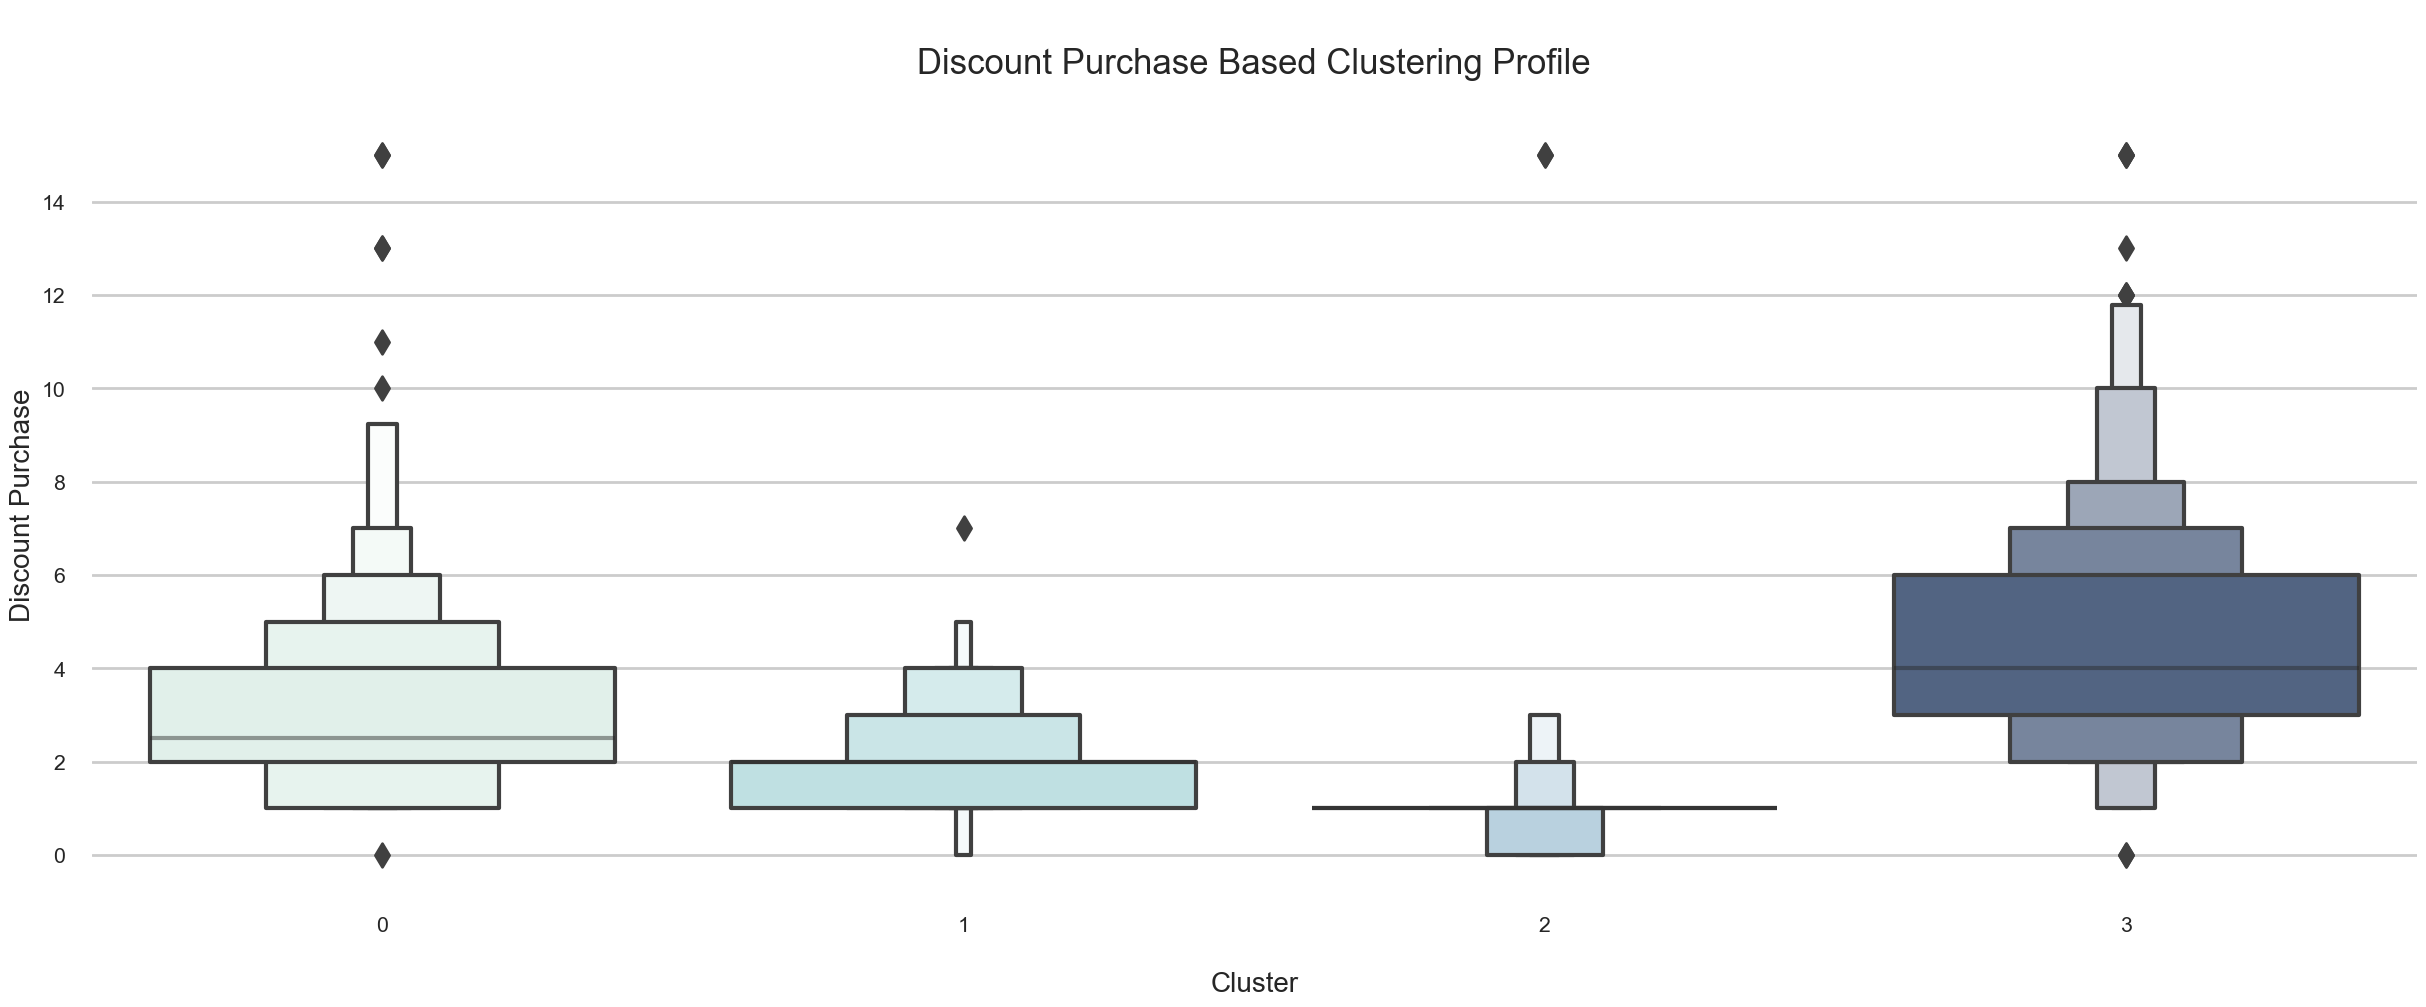

In [535]:
print(f"Let's have a look on the characteristics of the clusters on the basis of discount purchases :")

_, axes = plt.subplots(figsize=(30,10))
sns.boxenplot(x=data["Clusters"], y=data["Discount Purchases"], palette=["#DFF2EB", "#B9E5E8", "#7AB2D3", "#4A628A"])

axes.set_title("\nDiscount Purchase Based Clustering Profile\n", fontsize=25)
axes.set_ylabel("Discount Purchase", fontsize=20)
axes.set_xlabel("\nCluster", fontsize=20)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**
* change
* Most of the customers of cluster 0 have completed purchases using discount either 1/2 times. 
* Most of the customers of cluster 1 have completed purchases using discount only one times.
* Most of the customers of cluster 2 have completed purchases using discount 2 to 5 times. 
* Most of the customers of cluster 3 have completed purchases using discount 1 to 4 times.

In [536]:
def cluster(feature):
    
    _, axes = plt.subplots(figsize=(20,8))
    sns.kdeplot(x=data[feature], y=data["Spent"], hue =data["Clusters"], kind="kde",height=10, palette=["#DFF2EB", "#B9E5E8", "#7AB2D3", "#4A628A"])
    axes.set_title(f"\nClustering Profile On {feature}\n",fontsize=25)
    axes.set_ylabel("Spending",fontsize=20)
    axes.set_xlabel(f"\n{feature}",fontsize=20)
    
    sns.despine(left=True, bottom=True)
    plt.show()

Characteristics of clusters based on spending and having childern :


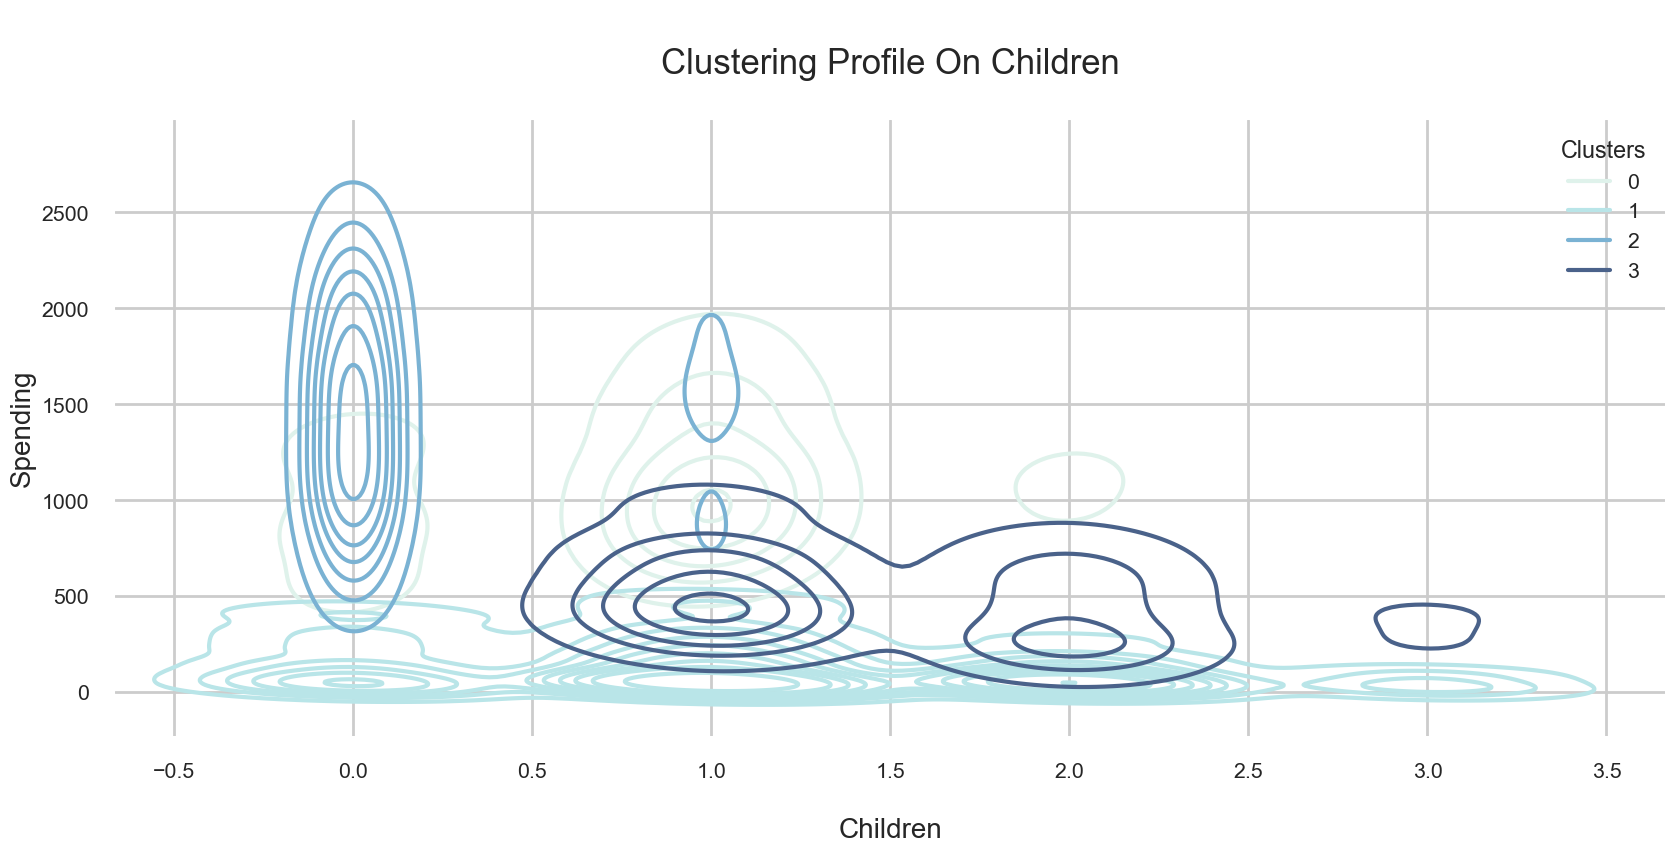

In [537]:
print(f"Characteristics of clusters based on spending and having childern :")
cluster("Children")

**Insights:**
* change
* Customers of cluster 0 either have one child or don't have any. Their spending range is in between 0 to 500.
* Most of the customers of cluster 1 don't have any child, only a few have one. Their spending range is in between 550 to 2000.
* Most of the customers of cluster 2 have one child, some have two. Their spending range is in between 250 to 1800.
* Most of the customers of cluster 3 have two child, some have one and very few have three. Their spending range is in between 0 to 500.


Characteristics of clusters based on spending and age :


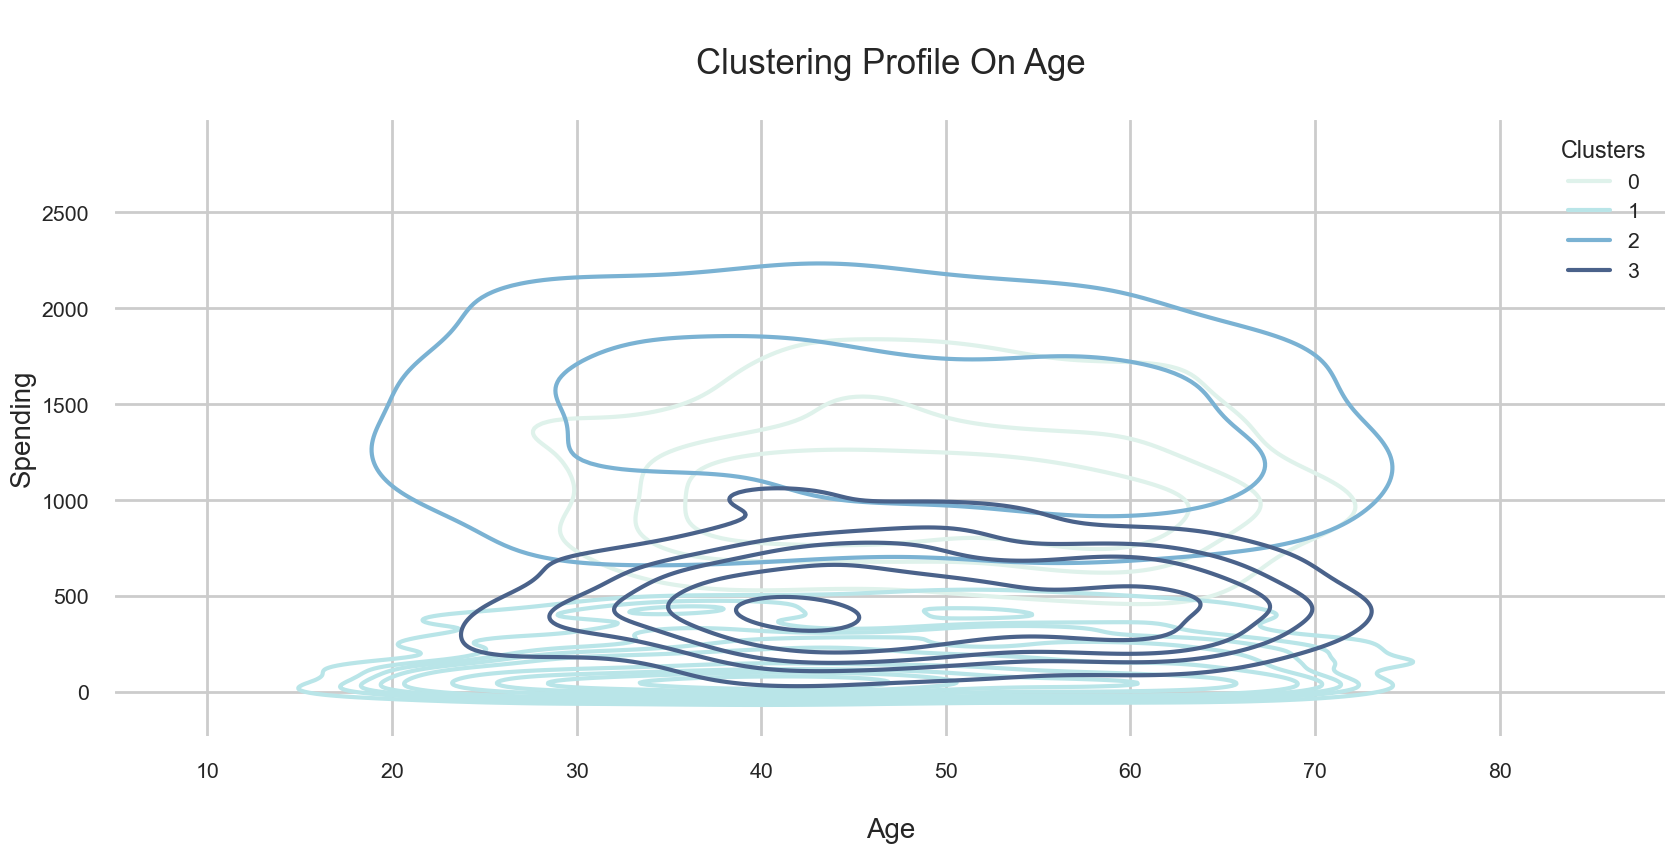

In [538]:
print(f"Characteristics of clusters based on spending and age :")
cluster("Age")

**Insights:**
* change
* Most of the customers of cluster 0 have age range in between 25 to 50. Their spending range is in between 0 to 500.
* Most of the customers of cluster 1 have age range in between 30 to 60. Their spending range is in between 550 to 2000.
* Most of the customers of cluster 2 have age range in between 35 to 60. Their spending range is in between 250 to 1800.
* Most of the customers of cluster 3 have age range in between 40 to 65. Their spending range is in between 0 to 500.


Characteristics of clusters based on spending and education level :


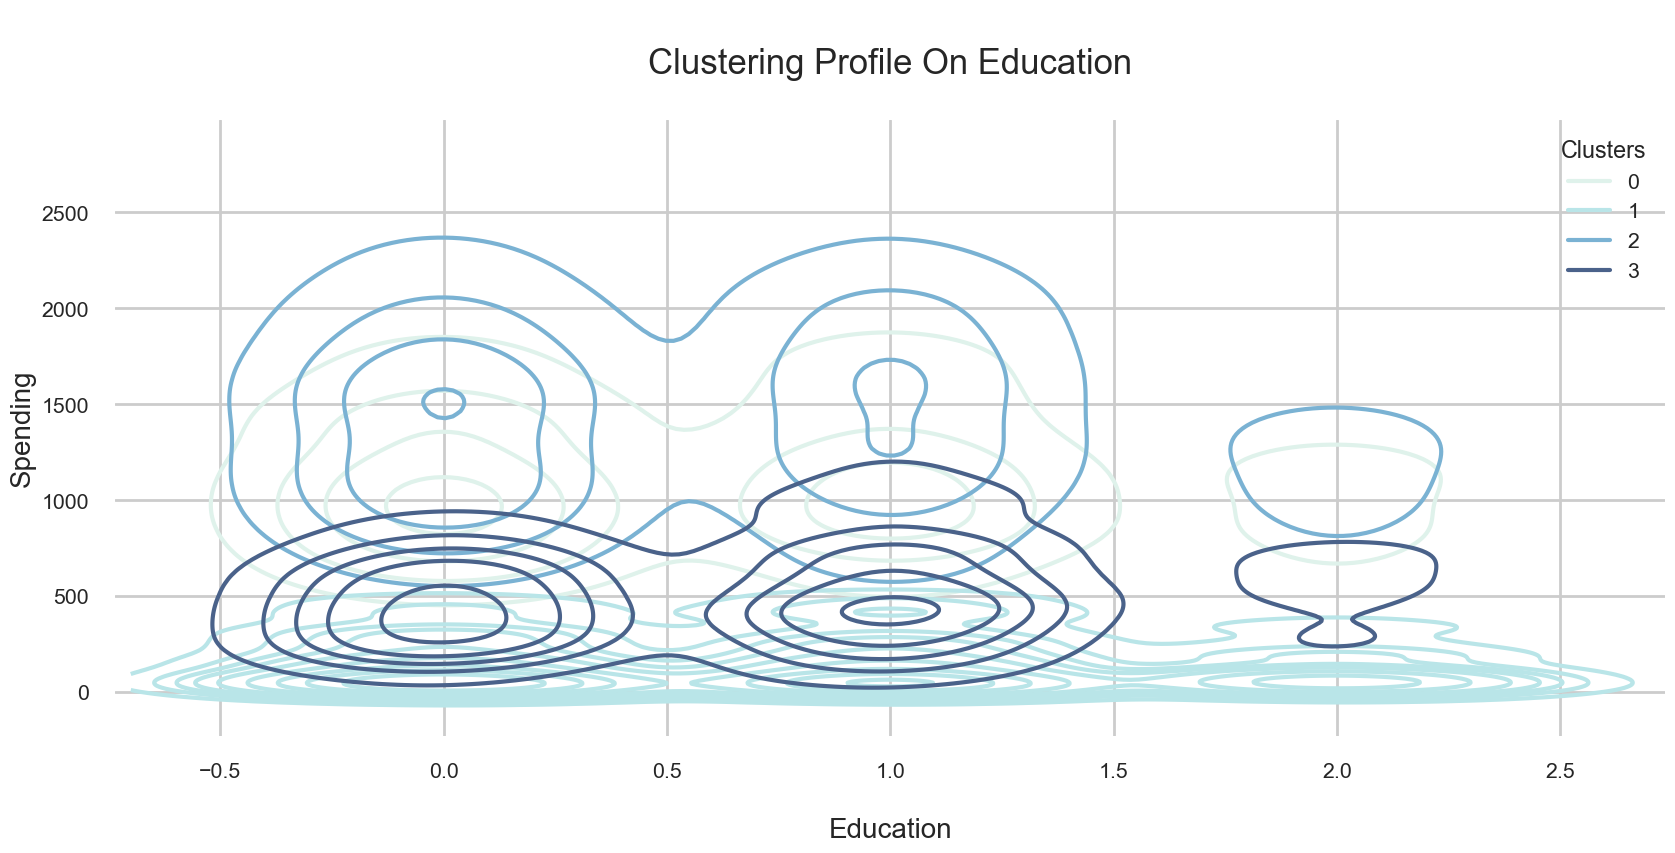

In [539]:
print(f"Characteristics of clusters based on spending and education level :")
cluster("Education")

**Insights:**
* change
* The customers of cluster 0 are graduate or in postgraduate level or in undergraduate level. Their spending range is in between 0 to 500.
* Most of the customers of cluster 1 are graduate or in postgraduate level. Their spending range is in between 550 to 2000.
* Most of the customers of cluster 2 are graduate and very few in postgraduate level. Their spending range is in between 250 to 1800.
* All the customers of cluster 3 are graduate or in postgraduate level and some are in undergraduate level. Their spending range is in between 0 to 500.

Characteristics of clusters based on spending and marital status :


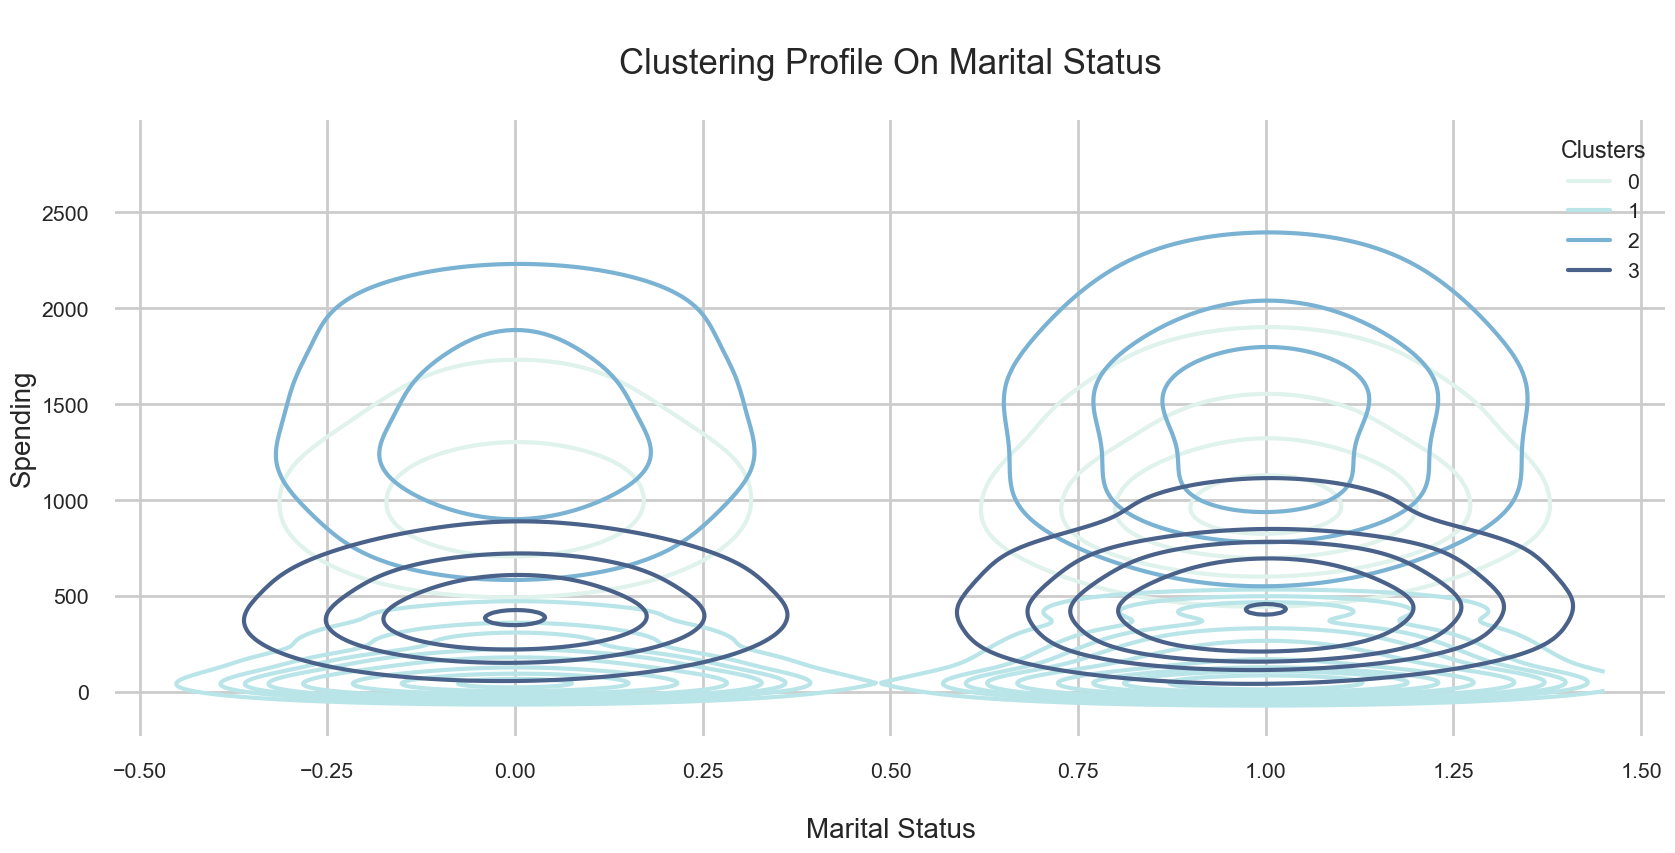

In [540]:
print(f"Characteristics of clusters based on spending and marital status :")
cluster("Marital Status")

**Insights:**

* Most of the customers of cluster 0 are married and very few are unmarried. Their spending range is in between 0 to 500.
* Most of the customers of cluster 1 are married. Their spending range is in between 550 to 2000.
* Most of the customers of cluster 2 are married. Their spending range is in between 250 to 1800.
* Some customers of cluster 3 are married and some are unmarried. Their spending range is in between 0 to 500.

**Insights:**

* Most of the customers of cluster 0 are parents and very few are not parents. Their spending range is in between 0 to 500.
* All the customers of cluster 1 are not parents. Their spending range is in between 550 to 2000.
* All the customers of cluster 2 are parents. Their spending range is in between 250 to 1800.
* All the customers of cluster 3 are parents. Their spending range is in between 0 to 500.

Characteristics of clusters based on spending and customer loyalty :


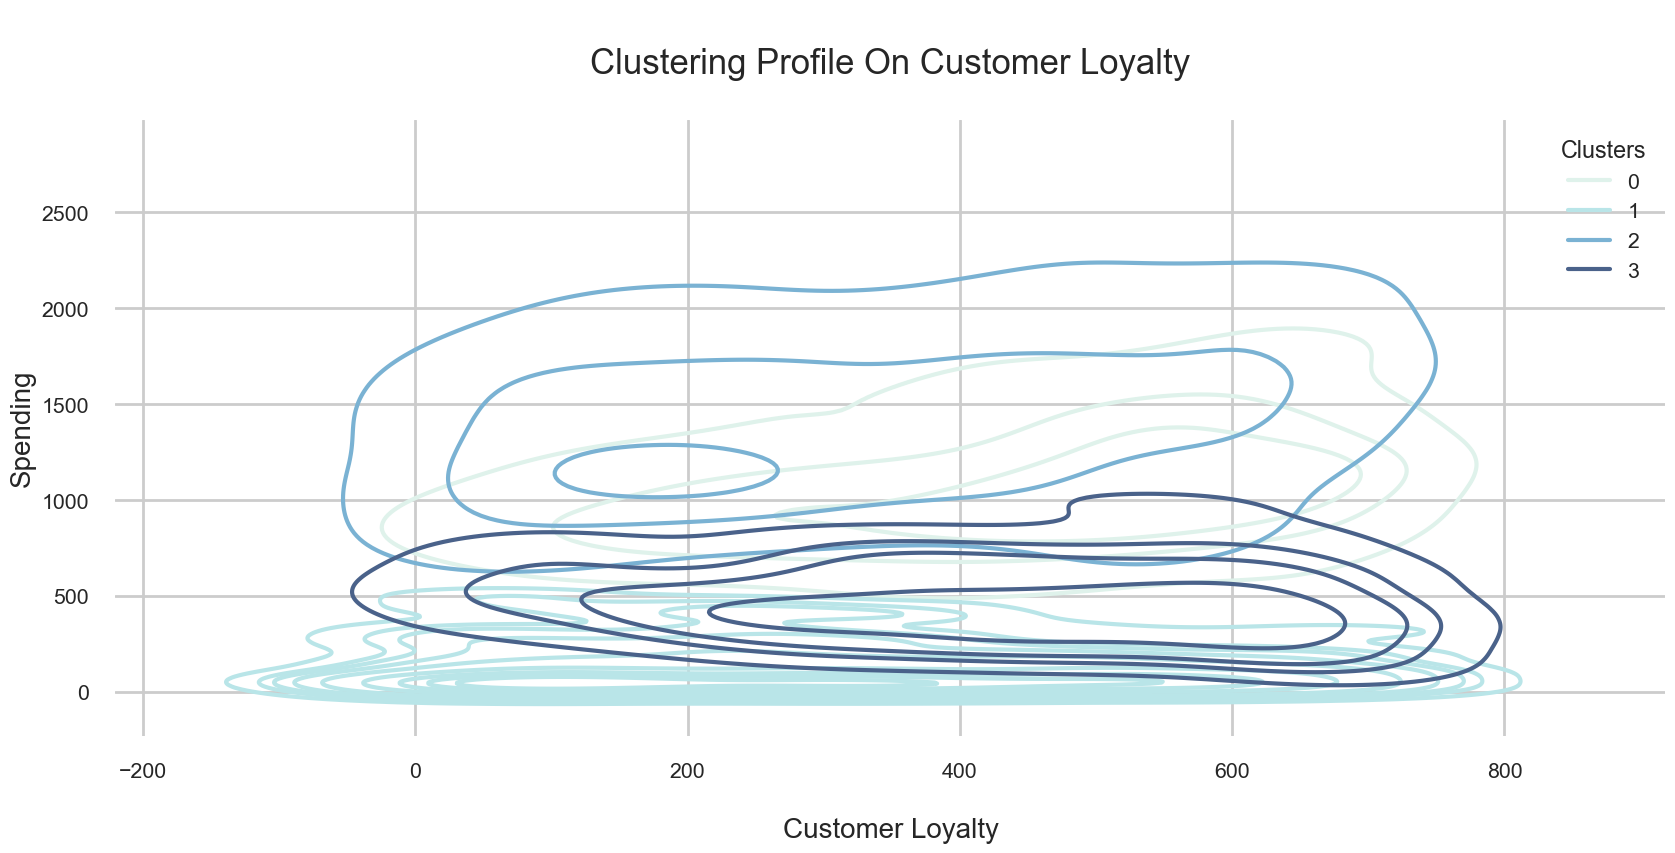

In [541]:
print(f"Characteristics of clusters based on spending and customer loyalty :")
cluster("Customer Loyalty")

**Insights:**
* change
* Most of the customers of cluster 0 are customer for 300 to 900 days. Their spending range is in between 0 to 500.
* Most of the customers of cluster 1 are customer for 250 to 750 days. Their spending range is in between 550 to 2000.
* Most of the customers of cluster 2 are customer for 400 to 800 days. Their spending range is in between 250 to 1800.
* Most of the customers of cluster 3 are customer for 150 to 650 days. Their spending range is in between 0 to 500.